# Preprocessing


## Imports and adding the data



In [103]:
!pip install tabulate

In [104]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [105]:
#Shakl plotting wahed
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [106]:
data ="/content/gluroo-data-export-2025-09-07_2025-12-06.csv"
try:
    df = pd.read_csv(data)
    print("CSV file loaded from Google Drive successfully")
except FileNotFoundError:
    print(f"Error: The file at '{data}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred while reading the CSV from Drive: {e}")

CSV file loaded from Google Drive successfully


## Data Exploration

In [107]:
df.head(5)

,date,bgl,trend,eventType,senderId,text,template,msgType,affectsFob,affectsIob,...,foodFat,foodProtein,foodSalt,foodCal,doseAutomatic,description,fpBgl,actionMins,exerciseMins,exerciseLevel
0,2025-09-07T20:37:57+00:00,131,FORTYFIVE_UP,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-07T20:49:23+00:00,134,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-09-07T20:50:24+00:00,136,FORTYFIVE_UP,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-09-07T20:53:25+00:00,147,FORTYFIVE_UP,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-09-07T20:56:25+00:00,157,SINGLE_UP,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
df.tail(5)

,date,bgl,trend,eventType,senderId,text,template,msgType,affectsFob,affectsIob,...,foodFat,foodProtein,foodSalt,foodCal,doseAutomatic,description,fpBgl,actionMins,exerciseMins,exerciseLevel
44324,2025-12-06T21:26:16+00:00,243,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44325,2025-12-06T21:28:18+00:00,242,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44326,2025-12-06T21:30:19+00:00,244,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44327,2025-12-06T21:33:20+00:00,244,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44328,2025-12-06T21:34:19+00:00,245,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [109]:
print("\n Data Info:")
print(f"   Columns: {list(df.columns)}")
print(f"\n Data Types:")
print(df.dtypes)


 Data Info:
   Columns: ['date', 'bgl', 'trend', 'eventType', 'senderId', 'text', 'template', 'msgType', 'affectsFob', 'affectsIob', 'doseUnits', 'foodG', 'foodSugar', 'foodFat', 'foodProtein', 'foodSalt', 'foodCal', 'doseAutomatic', 'description', 'fpBgl', 'actionMins', 'exerciseMins', 'exerciseLevel']

 Data Types:
date              object
bgl                int64
trend             object
eventType         object
senderId         float64
text              object
template          object
msgType           object
affectsFob        object
affectsIob        object
doseUnits        float64
foodG            float64
foodSugar        float64
foodFat          float64
foodProtein      float64
foodSalt         float64
foodCal          float64
doseAutomatic     object
description      float64
fpBgl            float64
actionMins       float64
exerciseMins     float64
exerciseLevel    float64
dtype: object


In [110]:
df.describe()

,bgl,senderId,doseUnits,foodG,foodSugar,foodFat,foodProtein,foodSalt,foodCal,description,fpBgl,actionMins,exerciseMins,exerciseLevel
count,44329.000000,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,194.933633,-0.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,62.888231,0.421637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,40.000000,-1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,150.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,194.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,239.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,419.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Checking the missing values

In [111]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing Percentage': missing_pct.values
}).sort_values('Missing Percentage', ascending=False)

print("\nMissing Values Summary:")
print(missing_df.to_string(index=False))


Missing Values Summary:
       Column  Missing Count  Missing Percentage
      foodCal          44329          100.000000
  description          44329          100.000000
  foodProtein          44329          100.000000
        foodG          44329          100.000000
    foodSugar          44329          100.000000
      foodFat          44329          100.000000
    doseUnits          44329          100.000000
 exerciseMins          44329          100.000000
   actionMins          44329          100.000000
exerciseLevel          44329          100.000000
        fpBgl          44329          100.000000
     foodSalt          44329          100.000000
     template          44321           99.981953
         text          44319           99.977441
     senderId          44319           99.977441
   affectsFob          44319           99.977441
      msgType          44319           99.977441
   affectsIob          44319           99.977441
doseAutomatic          44319           99.97

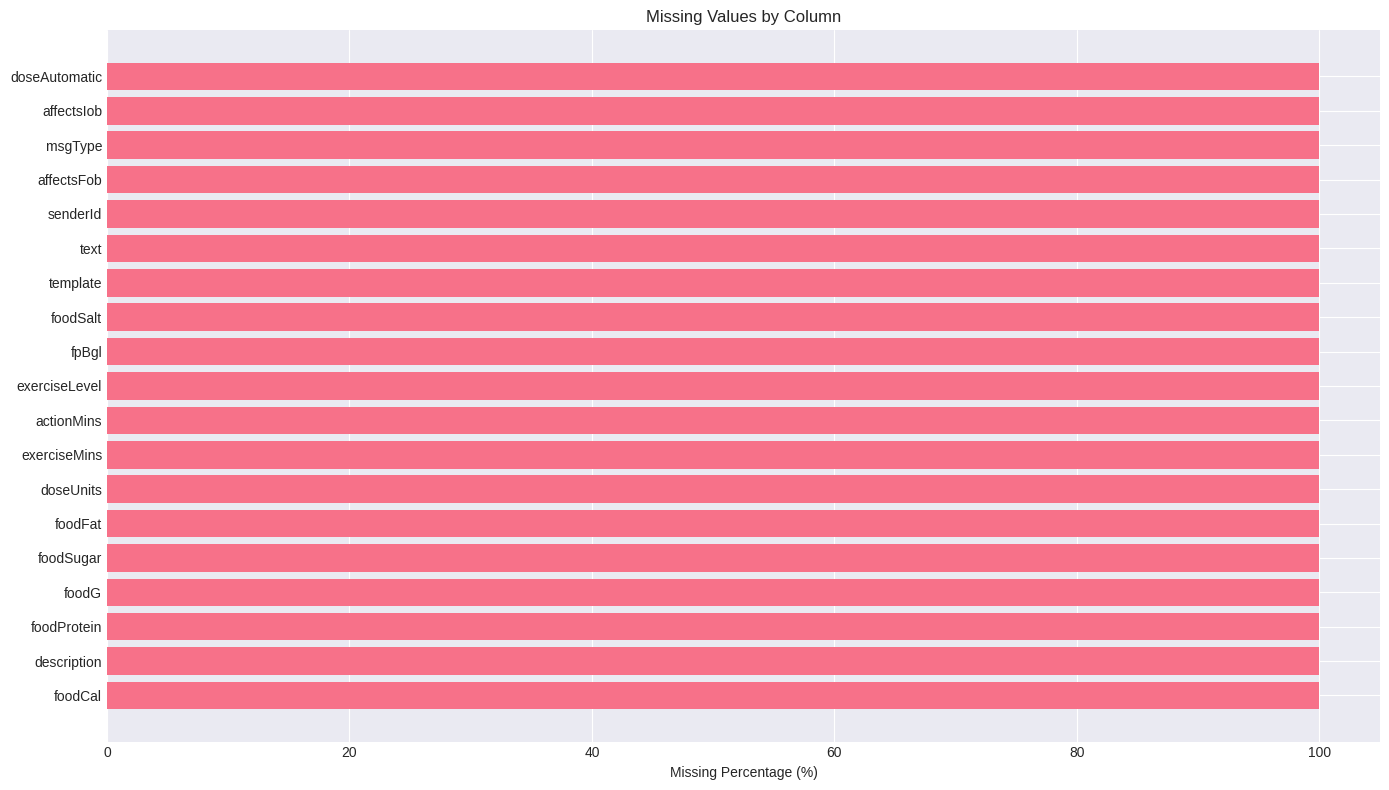

In [112]:
plt.figure(figsize=(14, 8))
missing_df_plot = missing_df[missing_df['Missing Percentage'] > 0]
if len(missing_df_plot) > 0:
    plt.barh(missing_df_plot['Column'], missing_df_plot['Missing Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

In [113]:
# feh columns fehaa missing values over ya3ny fo2 el 90% fa malhomsh lazma
high_missing_cols = missing_df[missing_df['Missing Percentage'] > 90]['Column'].tolist()
print(f"\n Columns with >90% missing values: {len(high_missing_cols)}")
print(f"   {high_missing_cols}")


 Columns with >90% missing values: 19
   ['foodCal', 'description', 'foodProtein', 'foodG', 'foodSugar', 'foodFat', 'doseUnits', 'exerciseMins', 'actionMins', 'exerciseLevel', 'fpBgl', 'foodSalt', 'template', 'text', 'senderId', 'affectsFob', 'msgType', 'affectsIob', 'doseAutomatic']


## Data Cleaning

In [114]:
# han5aly el data el mohema bs w hansheel el ba2y
essential_cols = ['date', 'bgl', 'trend', 'eventType']
cols_to_drop = [col for col in df.columns if col not in essential_cols]

print(f"Columns to drop: {len(cols_to_drop)}")
print(f"  {cols_to_drop}")

Columns to drop: 19
  ['senderId', 'text', 'template', 'msgType', 'affectsFob', 'affectsIob', 'doseUnits', 'foodG', 'foodSugar', 'foodFat', 'foodProtein', 'foodSalt', 'foodCal', 'doseAutomatic', 'description', 'fpBgl', 'actionMins', 'exerciseMins', 'exerciseLevel']


In [115]:
df_clean = df[essential_cols].copy()
print(f"\n✓ Cleaned dataset shape: {df_clean.shape}")
print(f"  Remaining columns: {list(df_clean.columns)}")



✓ Cleaned dataset shape: (44329, 4)
  Remaining columns: ['date', 'bgl', 'trend', 'eventType']


## Date and Time Processing


In [116]:
df_clean['date'] = pd.to_datetime(df_clean['date'], format='ISO8601', errors='coerce')


In [117]:
invalid_dates = df_clean['date'].isnull().sum()
if invalid_dates > 0:
    print(f"⚠ Warning: {invalid_dates} invalid dates found. Removing them...")
    df_clean = df_clean.dropna(subset=['date'])

In [118]:
print(f"\nDate Range:")
print(f"  Start: {df_clean['date'].min()}")
print(f"  End: {df_clean['date'].max()}")
print(f"  Duration: {(df_clean['date'].max() - df_clean['date'].min()).days} days")
print(f"  Total records: {len(df_clean):,}")



Date Range:
  Start: 2025-09-07 20:37:57+00:00
  End: 2025-12-06 21:34:19+00:00
  Duration: 90 days
  Total records: 44,329


## Duplicates checking

In [119]:
duplicates = df_clean.duplicated(subset=['date'], keep=False).sum()
print(f"\nDuplicate timestamps: {duplicates}")
if duplicates > 0:
    print("  Removing duplicates (keeping first occurrence)...")
    df_clean = df_clean.drop_duplicates(subset=['date'], keep='first')
    print(f"  Records after deduplication: {len(df_clean):,}")



Duplicate timestamps: 2
  Removing duplicates (keeping first occurrence)...
  Records after deduplication: 44,328


In [120]:
duplicates = df_clean.duplicated(subset=['date'], keep=False).sum()
print(f"\nDuplicate timestamps: {duplicates}")


Duplicate timestamps: 0


### sorting dates

In [121]:
df_clean = df_clean.sort_values('date').reset_index(drop=True)
print(f"\n Data sorted by timestamp")


 Data sorted by timestamp


# Blood Glucose Level Analysis (BGL)

In [122]:
bgl_stats = df_clean['bgl'].describe()
print(bgl_stats)

count    44328.000000
mean       194.934556
std         62.888640
min         40.000000
25%        150.000000
50%        194.000000
75%        239.000000
max        419.000000
Name: bgl, dtype: float64


In [123]:
print(f"\nAdditional Statistics:")
print(f"  Median: {df_clean['bgl'].median():.2f} mg/dL")
print(f"  Mode: {df_clean['bgl'].mode().values[0] if len(df_clean['bgl'].mode()) > 0 else 'N/A'} mg/dL")
print(f"  Unique values: {df_clean['bgl'].nunique()}")


Additional Statistics:
  Median: 194.00 mg/dL
  Mode: 194 mg/dL
  Unique values: 344


## Medical references

1. Normal fasting: 70-100 mg/dL
2. Normal post-meal: <140 mg/dL
3. Pre-diabetic: 100-125 mg/dL (fasting)
4. Diabetic: >125 mg/dL (fasting) or >200 mg/dL (random)

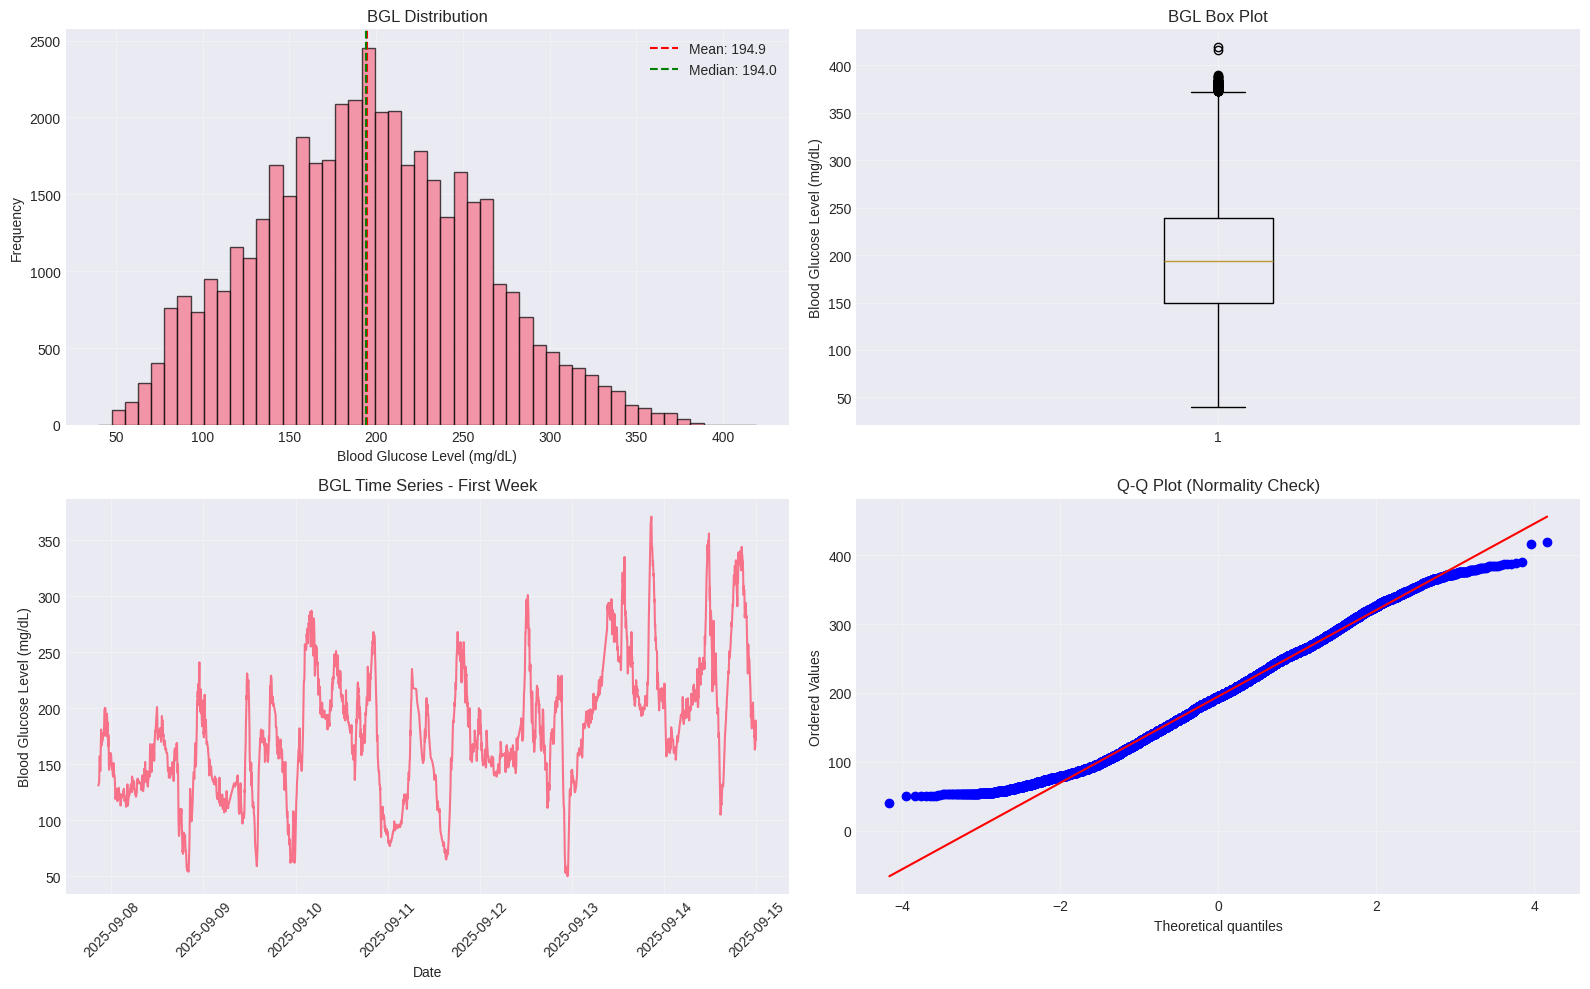

In [124]:
#Histogram
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].hist(df_clean['bgl'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_clean['bgl'].mean(), color='r', linestyle='--', label=f'Mean: {df_clean["bgl"].mean():.1f}')
axes[0, 0].axvline(df_clean['bgl'].median(), color='g', linestyle='--', label=f'Median: {df_clean["bgl"].median():.1f}')
axes[0, 0].set_xlabel('Blood Glucose Level (mg/dL)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('BGL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# Box plot
axes[0, 1].boxplot(df_clean['bgl'], vert=True)
axes[0, 1].set_ylabel('Blood Glucose Level (mg/dL)')
axes[0, 1].set_title('BGL Box Plot')
axes[0, 1].grid(True, alpha=0.3)

# Time series plot (first week)
df_clean_indexed = df_clean.set_index('date')
first_week = df_clean_indexed['bgl']['2025-09-07':'2025-09-14']
axes[1, 0].plot(first_week.index, first_week.values, linewidth=1.5)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Blood Glucose Level (mg/dL)')
axes[1, 0].set_title('BGL Time Series - First Week')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Q-Q plot for normality check
from scipy import stats
stats.probplot(df_clean['bgl'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Outliers Detection and Handling
### Medical bounds (physiologically reasonable range)
1. MEDICAL_MIN = 40  -> Severe hypoglycemia threshold

2. MEDICAL_MAX = 400 -> Severe hyperglycemia threshold

In [125]:
MEDICAL_MIN = 40
MEDICAL_MAX = 400

In [126]:
Q1 = df_clean['bgl'].quantile(0.25)
Q3 = df_clean['bgl'].quantile(0.75)
IQR = Q3 - Q1
LOWER_BOUND = Q1 - 1.5 * IQR
UPPER_BOUND = Q3 + 1.5 * IQR


In [127]:
print(f"  Minimum: {MEDICAL_MIN} mg/dL")
print(f"  Maximum: {MEDICAL_MAX} mg/dL")

  Minimum: 40 mg/dL
  Maximum: 400 mg/dL


In [128]:
print(f"  Q1: {Q1:.2f} mg/dL")
print(f"  Q3: {Q3:.2f} mg/dL")
print(f"  IQR: {IQR:.2f} mg/dL")
print(f"  Lower bound: {LOWER_BOUND:.2f} mg/dL")
print(f"  Upper bound: {UPPER_BOUND:.2f} mg/dL")

  Q1: 150.00 mg/dL
  Q3: 239.00 mg/dL
  IQR: 89.00 mg/dL
  Lower bound: 16.50 mg/dL
  Upper bound: 372.50 mg/dL


In [129]:
medical_outliers = df_clean[(df_clean['bgl'] < MEDICAL_MIN) | (df_clean['bgl'] > MEDICAL_MAX)]
statistical_outliers = df_clean[(df_clean['bgl'] < LOWER_BOUND) | (df_clean['bgl'] > UPPER_BOUND)]

print(f"\nOutlier Counts:")
print(f"  Medical outliers: {len(medical_outliers)} ({len(medical_outliers)/len(df_clean)*100:.2f}%)")
print(f"  Statistical outliers: {len(statistical_outliers)} ({len(statistical_outliers)/len(df_clean)*100:.2f}%)")



Outlier Counts:
  Medical outliers: 2 (0.00%)
  Statistical outliers: 66 (0.15%)


## Clipping values to medical bounds using the CAP method

In [130]:
bgl_before = df_clean['bgl'].copy()
df_clean['bgl'] = df_clean['bgl'].clip(lower=MEDICAL_MIN, upper=MEDICAL_MAX)
clipped_count = (bgl_before != df_clean['bgl']).sum()

In [131]:
print(f"\n Clipped {clipped_count} values to medical bounds")



 Clipped 2 values to medical bounds


/tmp/ipykernel_1623/329419955.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=['Before', 'After'])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


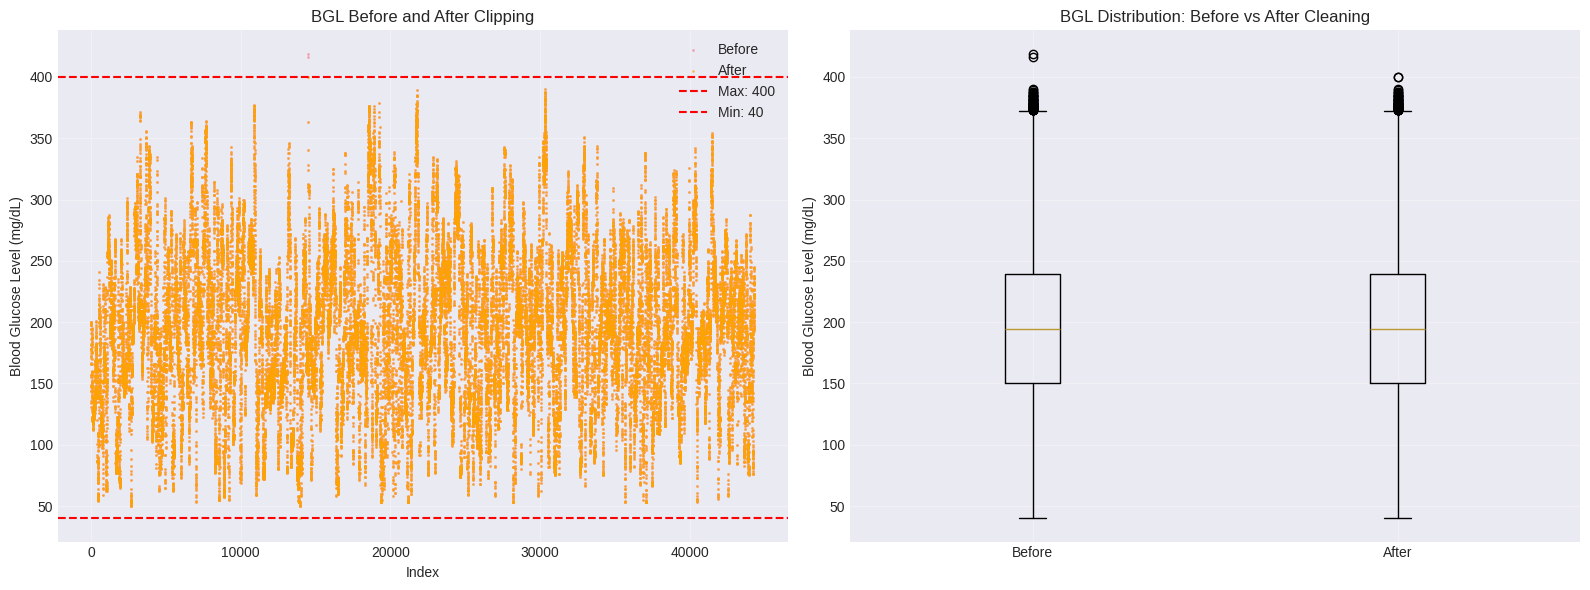

In [132]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before and after comparison
axes[0].scatter(range(len(bgl_before)), bgl_before, alpha=0.5, s=1, label='Before')
axes[0].scatter(range(len(df_clean['bgl'])), df_clean['bgl'], alpha=0.5, s=1, label='After', color='orange')
axes[0].axhline(MEDICAL_MAX, color='r', linestyle='--', label=f'Max: {MEDICAL_MAX}')
axes[0].axhline(MEDICAL_MIN, color='r', linestyle='--', label=f'Min: {MEDICAL_MIN}')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Blood Glucose Level (mg/dL)')
axes[0].set_title('BGL Before and After Clipping')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot comparison
box_data = [bgl_before, df_clean['bgl']]
axes[1].boxplot(box_data, labels=['Before', 'After'])
axes[1].set_ylabel('Blood Glucose Level (mg/dL)')
axes[1].set_title('BGL Distribution: Before vs After Cleaning')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Trend Type Distribution





In [133]:
print("\nEvent Type Distribution:")
event_counts = df_clean['eventType'].value_counts()
print(event_counts)
print(f"\n  Percentage:")
for event, count in event_counts.items():
    print(f"    {event}: {count/len(df_clean)*100:.2f}%")


Event Type Distribution:
eventType
cgm_reading    44319
message            9
Name: count, dtype: int64

  Percentage:
    cgm_reading: 99.98%
    message: 0.02%


In [134]:
print("\nTrend Distribution:")
trend_counts = df_clean['trend'].value_counts()
print(trend_counts)
print(f"\n  Percentage:")
for trend, count in trend_counts.items():
    print(f"    {trend}: {count/len(df_clean)*100:.2f}%")



Trend Distribution:
trend
FLAT              34101
NONE               3485
FORTYFIVE_UP       2526
FORTYFIVE_DOWN     2239
SINGLE_UP          1161
SINGLE_DOWN         816
Name: count, dtype: int64

  Percentage:
    FLAT: 76.93%
    NONE: 7.86%
    FORTYFIVE_UP: 5.70%
    FORTYFIVE_DOWN: 5.05%
    SINGLE_UP: 2.62%
    SINGLE_DOWN: 1.84%


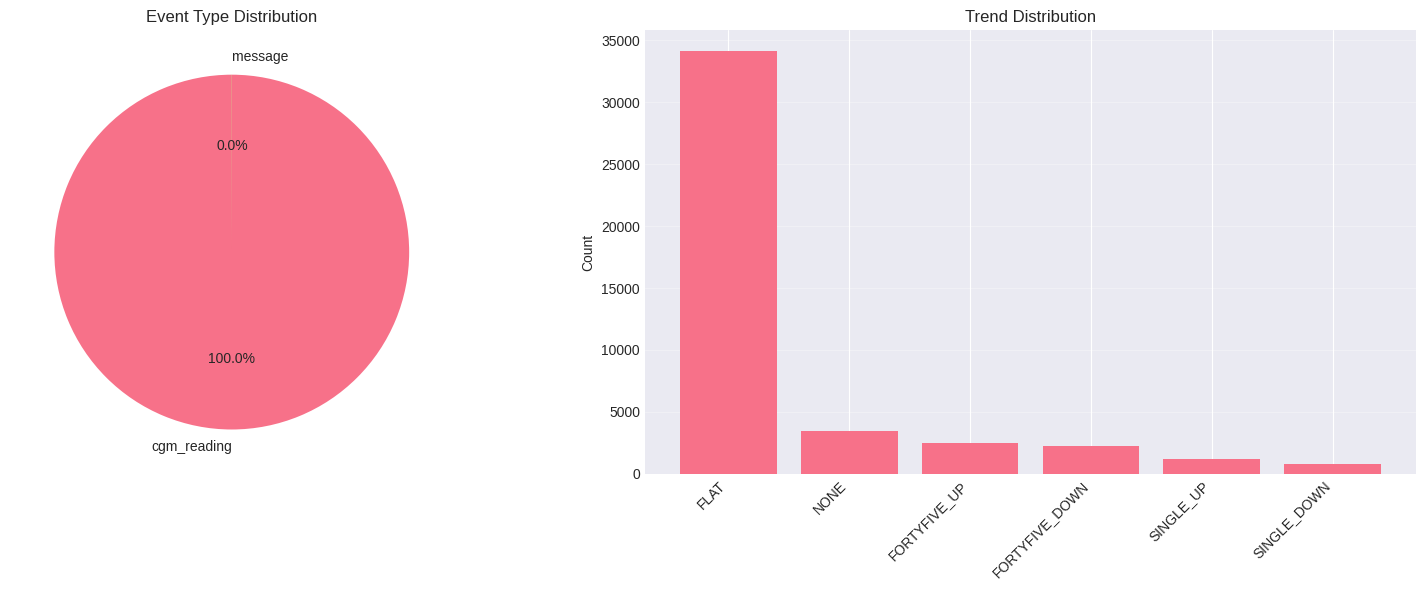

In [135]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Event type pie chart
axes[0].pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Event Type Distribution')

# Trend bar chart
axes[1].bar(range(len(trend_counts)), trend_counts.values)
axes[1].set_xticks(range(len(trend_counts)))
axes[1].set_xticklabels(trend_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title('Trend Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Time Series Preparation

In [136]:
#date indexing
df_ts = df_clean.set_index('date').sort_index()


In [137]:
# Keep only BGL for time series analysis
df_ts = df_ts[['bgl']].copy()

print(f"\nTime Series Info:")
print(f"  Start: {df_ts.index.min()}")
print(f"  End: {df_ts.index.max()}")
print(f"  Total records: {len(df_ts):,}")
print(f"  Time span: {(df_ts.index.max() - df_ts.index.min()).days} days")



Time Series Info:
  Start: 2025-09-07 20:37:57+00:00
  End: 2025-12-06 21:34:19+00:00
  Total records: 44,328
  Time span: 90 days


In [138]:
time_diffs = df_ts.index.to_series().diff()
median_interval = time_diffs.median()
mean_interval = time_diffs.mean()

print(f"\nTime Intervals:")
print(f"  Median: {median_interval}")
print(f"  Mean: {mean_interval}")


Time Intervals:
  Median: 0 days 00:02:01
  Mean: 0 days 00:02:55.499853362


In [139]:
print(f"No 5-minute resampling is performed here. Using original frequency for interpolation.")


Resampling to 5-minute intervals...


### Checking missing values after resampling

In [140]:
print(f"  Records after resampling: {len(df_resampled):,}")
print(f"  Missing values: {df_resampled.isna().sum():,} ({df_resampled.isna().sum()/len(df_resampled)*100:.2f}%)")


  Records after resampling: 25,932
  Missing values: 6,306 (24.32%)


### Handling missing values with interpolation

In [141]:
print(f"\nInterpolating missing values...")
df_ts['bgl'] = df_ts['bgl'].interpolate(method='linear', limit_direction='both', limit=12)  # Max 1 hour gap


Interpolating missing values...


In [142]:
df_ts['bgl'] = df_ts['bgl'].ffill().bfill()

In [143]:
df_ts_clean = df_ts.copy()
print(f"  Missing values after interpolation: {df_ts_clean['bgl'].isna().sum()}")
print(f"  Final shape: {df_ts_clean.shape}")

  Missing values after interpolation: 0
  Final shape: (44328, 1)


### Resampling to 30-minute intervals

In [144]:
# Resample to 30-minute intervals to match the prediction horizon
df_ts_30min = df_ts_clean['bgl'].resample('30min').mean()

print(f"Records after 30-minute resampling: {len(df_ts_30min):,}")
print(f"Missing values after 30-minute resampling: {df_ts_30min.isna().sum():,} ({df_ts_30min.isna().sum()/len(df_ts_30min)*100:.2f}%)")

# Interpolate any new missing values if they arise from resampling
df_ts_30min = df_ts_30min.interpolate(method='linear', limit_direction='both')
df_ts_30min = df_ts_30min.ffill().bfill()

print(f"Missing values after interpolation (30-min): {df_ts_30min.isna().sum()}")

# Convert back to DataFrame
df_ts_clean_30min = pd.DataFrame({'bgl': df_ts_30min})
print(f"Final 30-minute resampled shape: {df_ts_clean_30min.shape}")

Records after 30-minute resampling: 4,323
Missing values after 30-minute resampling: 465 (10.76%)
Missing values after interpolation (30-min): 0
Final 30-minute resampled shape: (4323, 1)


## Time Series Visualization

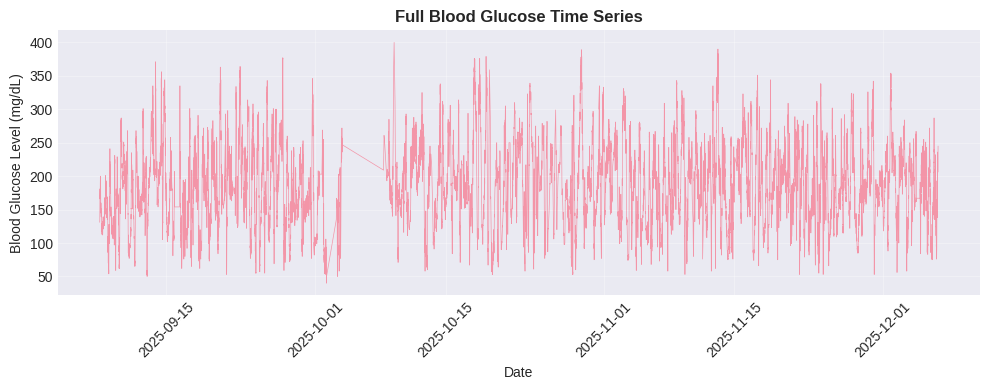

In [145]:
# Full time series
plt.figure(figsize=(10, 4))
plt.plot(df_ts_clean.index, df_ts_clean['bgl'], linewidth=0.5, alpha=0.7)
plt.title('Full Blood Glucose Time Series', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


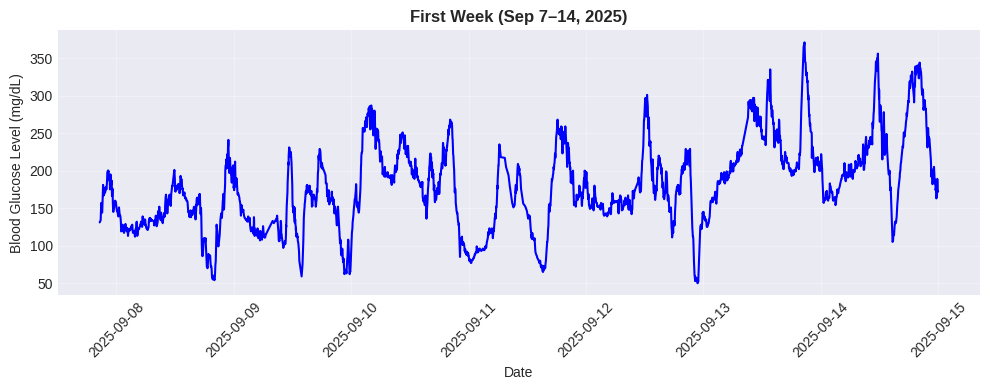

In [146]:
#  First week
first_week_data = df_ts_clean['2025-09-07':'2025-09-14']

plt.figure(figsize=(10, 4))
plt.plot(first_week_data.index, first_week_data['bgl'],color='blue', linewidth=1.5)
plt.title('First Week (Sep 7–14, 2025)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


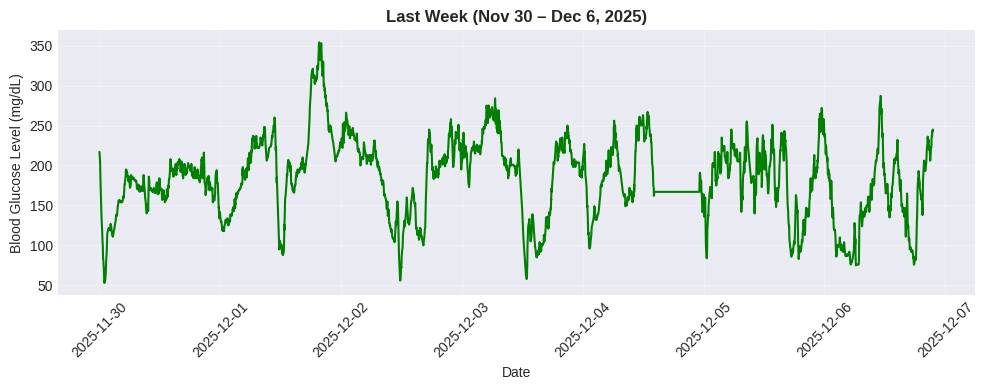

In [147]:
# Last week
last_week_data = df_ts_clean['2025-11-30':'2025-12-06']

plt.figure(figsize=(10, 4))
plt.plot(last_week_data.index, last_week_data['bgl'], color='green', linewidth=1.5)
plt.title('Last Week (Nov 30 – Dec 6, 2025)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


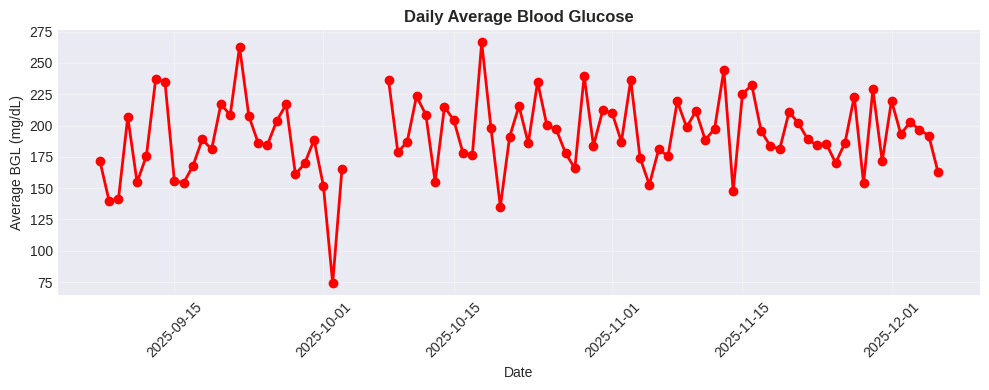

In [148]:
# Daily average
daily_avg = df_ts_clean['bgl'].resample('D').mean()

plt.figure(figsize=(10, 4))
plt.plot(daily_avg.index, daily_avg.values, linewidth=2,color='red', marker='o')
plt.title('Daily Average Blood Glucose', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average BGL (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


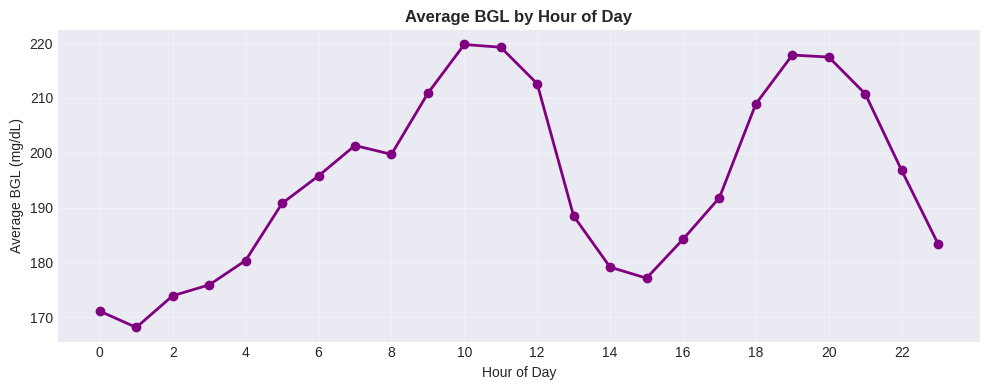

In [149]:
#  Hourly pattern
hourly_avg = df_ts_clean.groupby(df_ts_clean.index.hour)['bgl'].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, linewidth=2,color='purple', marker='o')
plt.title('Average BGL by Hour of Day', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average BGL (mg/dL)')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


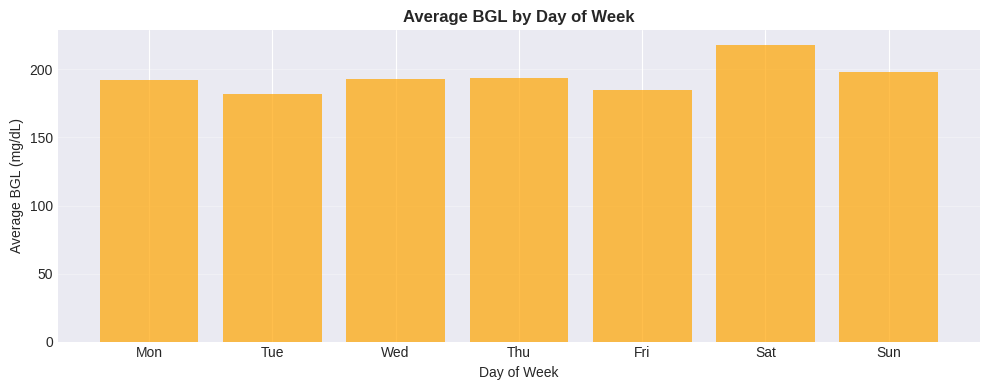

In [150]:
# Weekly pattern
weekly_avg = df_ts_clean.groupby(df_ts_clean.index.dayofweek)['bgl'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 4))
plt.bar(day_names, weekly_avg.values, color= 'orange',alpha=0.7)
plt.title('Average BGL by Day of Week', fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average BGL (mg/dL)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Stationarity Check

In [151]:
def adf_test(timeseries, title="Time Series"):
    """Perform Augmented Dickey-Fuller test for stationarity"""
    result = adfuller(timeseries.dropna(), autolag='AIC')

    print(f"\n{title}:")
    print(f"  ADF Statistic: {result[0]:.6f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.6f}")

    if result[1] <= 0.05:
        print(f" Result: Stationary (p-value <= 0.05)")
        return True
    else:
        print(f" Result: Non-stationary (p-value > 0.05)")
        return False

In [152]:
is_stationary = adf_test(df_ts_clean['bgl'], "Original BGL Series")

# If not stationary, try differencing
if not is_stationary:
    print("\n" + "-" * 80)
    print("Testing first difference...")
    df_ts_clean['bgl_diff'] = df_ts_clean['bgl'].diff()
    is_stationary_diff = adf_test(df_ts_clean['bgl_diff'].dropna(), "First Difference")


Original BGL Series:
  ADF Statistic: -17.091507
  p-value: 0.000000
  Critical Values:
    1%: -3.430498
    5%: -2.861605
    10%: -2.566805
 Result: Stationary (p-value <= 0.05)


## Time Series Decomposition


Decomposing time series (using first 5000 points)...
  Period: 288 (24 hours in 5-minute intervals)


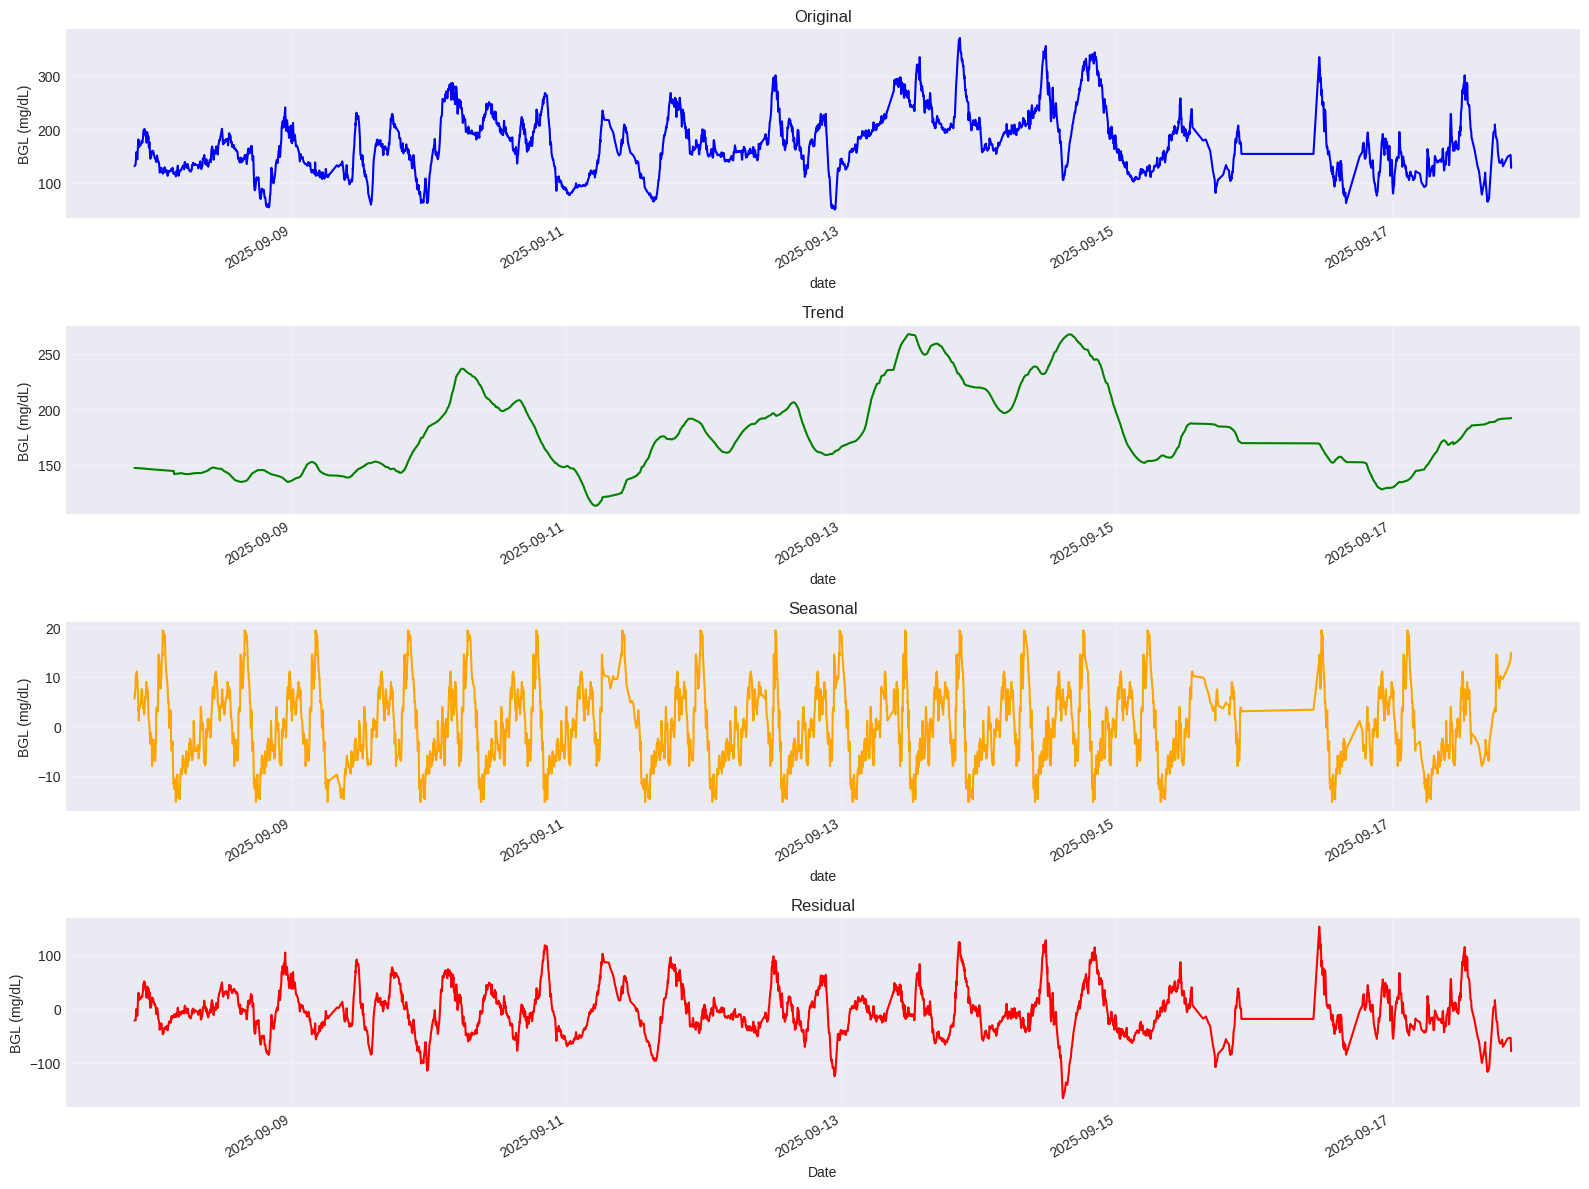

 Decomposition completed successfully!


In [153]:
period = 288

decomp_data = df_ts_clean['bgl'].iloc[:5000]

print(f"\nDecomposing time series (using first {len(decomp_data)} points)...")
print(f"  Period: {period} (24 hours in 5-minute intervals)")

try:
    decomposition = seasonal_decompose(decomp_data, model='additive', period=period, extrapolate_trend='freq')

    # Plot decomposition
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))

    decomposition.observed.plot(ax=axes[0], title='Original', color='blue')
    axes[0].set_ylabel('BGL (mg/dL)')
    axes[0].grid(True, alpha=0.3)

    decomposition.trend.plot(ax=axes[1], title='Trend', color='green')
    axes[1].set_ylabel('BGL (mg/dL)')
    axes[1].grid(True, alpha=0.3)

    decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='orange')
    axes[2].set_ylabel('BGL (mg/dL)')
    axes[2].grid(True, alpha=0.3)

    decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
    axes[3].set_ylabel('BGL (mg/dL)')
    axes[3].set_xlabel('Date')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(" Decomposition completed successfully!")

except Exception as e:
    print(f"Warning: Decomposition failed: {e}")
    print("  This might be due to insufficient data or period mismatch")



## Autocorrelation Analysis

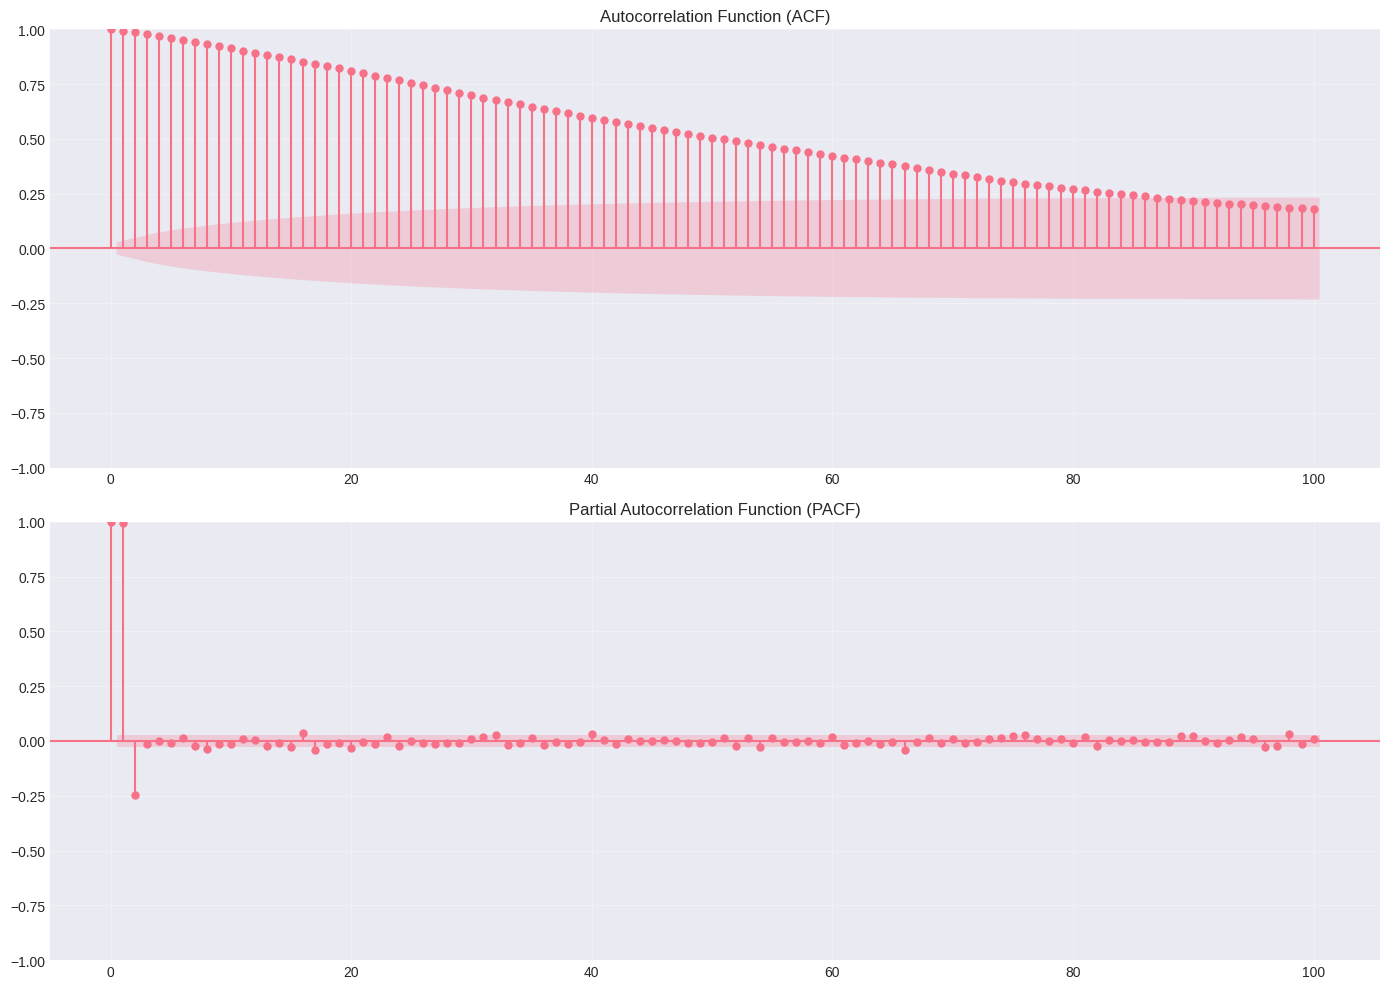

In [154]:
acf_data = df_ts_clean['bgl'].iloc[:5000]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF Plot
plot_acf(acf_data.dropna(), lags=100, ax=axes[0], title='Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF Plot
plot_pacf(acf_data.dropna(), lags=100, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [155]:
df_export = df_ts_clean.reset_index()
df_export.columns = ['date', 'bgl']

# Make the 'date' column timezone-naive before extracting date/time components
df_export['date'] = df_export['date'].dt.tz_localize(None)

df_export['hour'] = df_export['date'].dt.hour
df_export['day_of_week'] = df_export['date'].dt.dayofweek
df_export['day_name'] = df_export['date'].dt.day_name()
df_export['month'] = df_export['date'].dt.month
df_export['day'] = df_export['date'].dt.day

df_export = df_export[['date', 'bgl', 'hour', 'day_of_week', 'day_name', 'month', 'day']]

print(f"\nPrepared data for export:")
print(f"  Shape: {df_export.shape[0]:,} rows \u00d7 {df_export.shape[1]} columns")
print(f"  Date range: {df_export['date'].min()} to {df_export['date'].max()}")
print(f"\nFirst few rows:")
print(df_export.head())

output_file = "gluroo_data_cleaned.xlsx"

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        df_export.to_excel(writer, sheet_name='Cleaned_Data', index=False)

        summary_stats = pd.DataFrame({
            'Metric': ['Total Records', 'Date Range Start', 'Date Range End',
                      'Mean BGL', 'Median BGL', 'Std BGL', 'Min BGL', 'Max BGL'],
            'Value': [
                len(df_export),
                str(df_export['date'].min()),
                str(df_export['date'].max()),
                f"{df_export['bgl'].mean():.2f} mg/dL",
                f"{df_export['bgl'].median():.2f} mg/dL",
                f"{df_export['bgl'].std():.2f} mg/dL",
                f"{df_export['bgl'].min():.2f} mg/dL",
                f"{df_export['bgl'].max():.2f} mg/dL"
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary_Statistics', index=False)

        hourly_avg = df_export.groupby('hour')['bgl'].agg(['mean', 'std', 'count']).reset_index()
        hourly_avg.columns = ['Hour', 'Mean_BGL', 'Std_BGL', 'Count']
        hourly_avg.to_excel(writer, sheet_name='Hourly_Averages', index=False)

        daily_avg = df_export.groupby(df_export['date'].dt.date)['bgl'].agg(['mean', 'std', 'count']).reset_index()
        daily_avg.columns = ['Date', 'Mean_BGL', 'Std_BGL', 'Count']
        daily_avg.to_excel(writer, sheet_name='Daily_Averages', index=False)

        if 'future_forecast_extract' in globals():
            forecast_export = future_forecast_extract.reset_index()
            forecast_export.columns = ['date', 'forecast', 'lower_bound', 'upper_bound']
            forecast_export.to_excel(writer, sheet_name='Future_Forecast', index=False)

    print(f"\n Data exported successfully to: {output_file}")
    print(f"  File contains {len(pd.ExcelFile(output_file).sheet_names)} sheets:")
    for sheet in pd.ExcelFile(output_file).sheet_names:
        print(f"    - {sheet}")

except Exception as e:
    print(f"\n Error exporting to Excel: {e}")
    print("  Trying CSV export instead...")
    try:
        csv_file = "gluroo_data_cleaned.csv"
        df_export.to_csv(csv_file, index=False)
        print(f"Data exported to CSV: {csv_file}")
    except Exception as e2:
        print(f"CSV export also failed: {e2}")


Prepared data for export:
  Shape: 44,328 rows × 7 columns
  Date range: 2025-09-07 20:37:57+00:00 to 2025-12-06 21:34:19+00:00

First few rows:
                       date  bgl  hour  day_of_week day_name  month  day
0 2025-09-07 20:37:57+00:00  131    20            6   Sunday      9    7
1 2025-09-07 20:49:23+00:00  134    20            6   Sunday      9    7
2 2025-09-07 20:50:24+00:00  136    20            6   Sunday      9    7
3 2025-09-07 20:53:25+00:00  147    20            6   Sunday      9    7
4 2025-09-07 20:56:25+00:00  157    20            6   Sunday      9    7

 Error exporting to Excel: Excel does not support datetimes with timezones. Please ensure that datetimes are timezone unaware before writing to Excel.
  Trying CSV export instead...
Data exported to CSV: gluroo_data_cleaned.csv


## Preparing the data for preprocessing

In [156]:
split_point = int(len(df_ts_clean_30min) * 0.8)
train_data = df_ts_clean_30min.iloc[:split_point].copy()
test_data = df_ts_clean_30min.iloc[split_point:].copy()

print(f"\nData Split:")
print(f"  Training set: {len(train_data):,} records ({len(train_data)/len(df_ts_clean_30min)*100:.1f} generalised data for 30-minute intervals%) ")
print(f"  Test set: {len(test_data):,} records ({len(test_data)/len(df_ts_clean_30min)*100:.1f} generalised data for 30-minute intervals%) ")
print(f"  Training period: {train_data.index.min()} to {train_data.index.max()}")
print(f"  Test period: {test_data.index.min()} to {test_data.index.max()}")


Data Split:
  Training set: 35,462 records (80.0%)
  Test set: 8,866 records (20.0%)
  Training period: 2025-09-07 20:37:57+00:00 to 2025-11-21 16:02:48+00:00
  Test period: 2025-11-21 16:04:48+00:00 to 2025-12-06 21:34:19+00:00


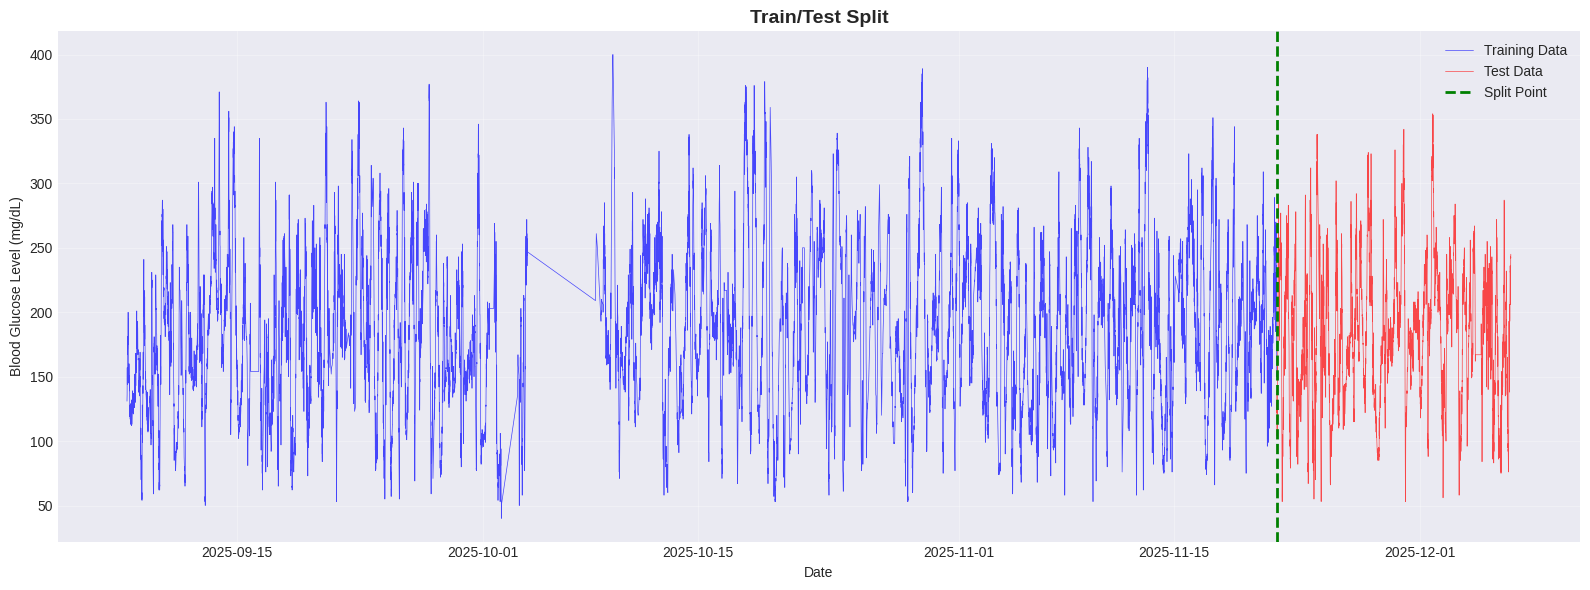

In [157]:
plt.figure(figsize=(16, 6))
plt.plot(train_data.index, train_data['bgl'], label='Training Data', color='blue', alpha=0.7, linewidth=0.5)
plt.plot(test_data.index, test_data['bgl'], label='Test Data', color='red', alpha=0.7, linewidth=0.5)
plt.axvline(train_data.index.max(), color='green', linestyle='--', linewidth=2, label='Split Point')
plt.title('Train/Test Split', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [158]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data[['bgl']])
test_scaled  = scaler.transform(test_data[['bgl']])


In [159]:
import numpy as np

HORIZON = 1  # For 30-minute resampled data, 1 step ahead is 30 minutes

def create_sequences(data, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size+horizon-1])
    return np.array(X), np.array(y)

In [160]:
WINDOW_SIZE = 24  # 12 hours of input (24 * 30-minute intervals = 720 minutes)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, horizon=HORIZON)
X_test, y_test   = create_sequences(test_scaled, WINDOW_SIZE, horizon=HORIZON)

In [161]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("FORECASTING METHOD 1: LSTM")

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Forecast
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test)

# Metrics
lstm_mae = mean_absolute_error(y_test_inv, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv, lstm_pred))
lstm_mape = np.mean(np.abs((y_test_inv - lstm_pred) / y_test_inv)) * 100

print(f"LSTM MAE: {lstm_mae:.2f}")
print(f"LSTM RMSE: {lstm_rmse:.2f}")
print(f"LSTM MAPE: {lstm_mape:.2f}%")

FORECASTING METHOD 1: LSTM
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0089 - val_loss: 0.0034
Epoch 2/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0044 - val_loss: 0.0030
Epoch 3/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0039 - val_loss: 0.0027
Epoch 4/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0036 - val_loss: 0.0026
Epoch 5/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0035 - val_loss: 0.0026
Epoch 6/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0034 - val_loss: 0.0024
Epoch 7/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 8/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 9/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0033 - val_loss: 0.0026
Epoch 10/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 11/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 12/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.

In [162]:
from tensorflow.keras.layers import GRU

print("GRU")

gru_model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

history_gru = gru_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

gru_pred_scaled = gru_model.predict(X_test)
gru_pred = scaler.inverse_transform(gru_pred_scaled)

gru_mae = mean_absolute_error(y_test_inv, gru_pred)
gru_rmse = np.sqrt(mean_squared_error(y_test_inv, gru_pred))
gru_mape = np.mean(np.abs((y_test_inv - gru_pred) / y_test_inv)) * 100

print(f"GRU MAE: {gru_mae:.2f}")
print(f"GRU RMSE: {gru_rmse:.2f}")
print(f"GRU MAPE: {gru_mape:.2f}%")

GRU
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0072 - val_loss: 0.0027
Epoch 2/40
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0035 - val_loss: 0.0025
Epoch 3/40
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0034 - val_loss: 0.0024
Epoch 4/40
499/499 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0033 - val_loss: 0.0026
Epoch 5/40
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0033 - val_loss: 0.0024
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GRU MAE: 14.05
GRU RMSE: 19.80
GRU MAPE: 8.45%


In [163]:
!pip install hmmlearn


In [164]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

best_bic = np.inf
best_n = 0
bic_list = []

# Extended state search (2–10) with full covariance and more iterations
for n in range(2, 11):  # test 2 to 10 states
    try:
        model = GaussianHMM(n_components=n, covariance_type='full', n_iter=1500,
                            random_state=42, tol=1e-5)
        model.fit(train_scaled)
        bic = model.bic(train_scaled)
        bic_list.append((n, bic))
        if bic < best_bic:
            best_bic = bic
            best_n = n
    except Exception as e:
        print(f"  Skipping n={n}: {e}")

print(f"Optimal number of states by BIC: {best_n}")

# Final model: full covariance, high iteration count, multiple init attempts
best_hmm = None
best_score = -np.inf
for seed in [42, 7, 13, 99, 21]:  # multiple random restarts to escape local optima
    try:
        candidate = GaussianHMM(n_components=best_n, covariance_type='full',
                                n_iter=1500, random_state=seed, tol=1e-5)
        candidate.fit(train_scaled)
        score = candidate.score(train_scaled)
        if score > best_score:
            best_score = score
            best_hmm = candidate
    except Exception:
        continue

hmm_model = best_hmm
print(f"Best log-likelihood on train: {best_score:.2f}")

state_probs = hmm_model.predict_proba(test_scaled)  # shape: (n_samples, n_states)
hmm_means = hmm_model.means_.flatten()              # mean of each state

hmm_pred_weighted = (state_probs * hmm_means).sum(axis=1)  # weighted sum across states

# Wider smoothing window (5 instead of 3) for cleaner predictions
window = 5
hmm_pred_smooth = np.convolve(hmm_pred_weighted, np.ones(window)/window, mode='same')

hmm_pred_final = scaler.inverse_transform(hmm_pred_smooth.reshape(-1, 1))

test_actual = test_data['bgl'].iloc[:len(hmm_pred_final)]

hmm_mae  = mean_absolute_error(test_actual, hmm_pred_final)
hmm_rmse = np.sqrt(mean_squared_error(test_actual, hmm_pred_final))
hmm_mape = np.mean(np.abs((test_actual - hmm_pred_final.flatten()) / test_actual)) * 100

print(f"HMM MAE:  {hmm_mae:.2f}")
print(f"HMM RMSE: {hmm_rmse:.2f}")
print(f"HMM MAPE: {hmm_mape:.2f}%")
print(f"HMM Accuracy: {100 - hmm_mape:.2f}%")


Optimal number of states by BIC: 10


Best log-likelihood on train: 73561.00
HMM MAE:  5.17
HMM RMSE: 7.01
HMM MAPE: 3.16%
HMM Accuracy: 96.84%


In [165]:

lstm_accuracy = 100 - lstm_mape
gru_accuracy  = 100 - gru_mape
hmm_accuracy  = 100 - hmm_mape

print(f"LSTM Accuracy: {lstm_accuracy:.2f}%")
print(f"GRU Accuracy: {gru_accuracy:.2f}%")
print(f"HMM Accuracy: {hmm_accuracy:.2f}%")


LSTM Accuracy: 92.10%
GRU Accuracy: 91.55%
HMM Accuracy: 96.84%


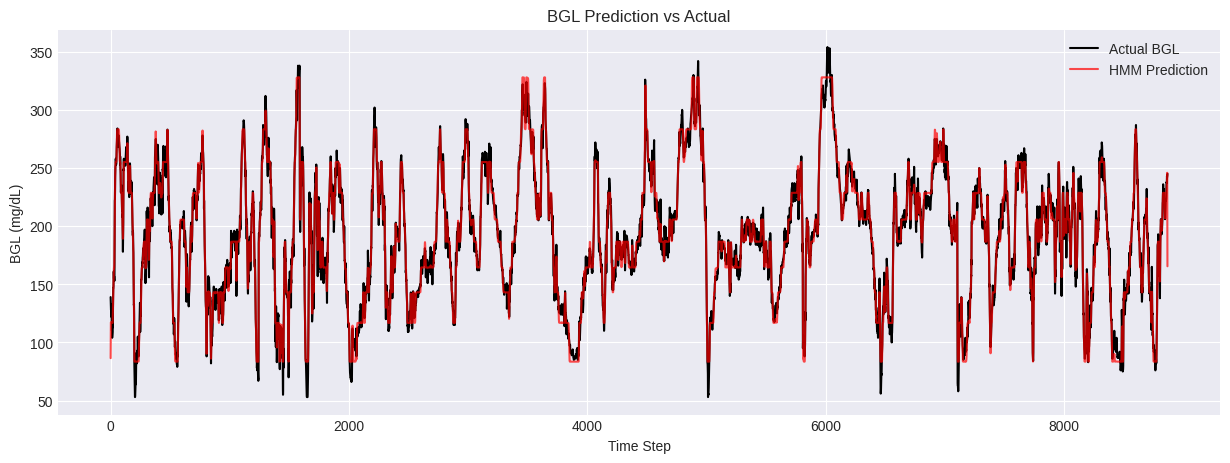

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(test_data['bgl'].values[:len(hmm_pred_final)], label='Actual BGL', color='black')
plt.plot(hmm_pred_final, label='HMM Prediction', color='red', alpha=0.7)
# If you have other models, plot them too:
# plt.plot(model2_pred, label='Random Forest', color='blue', alpha=0.7)
# plt.plot(model3_pred, label='ARIMA', color='green', alpha=0.7)
plt.title("BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()


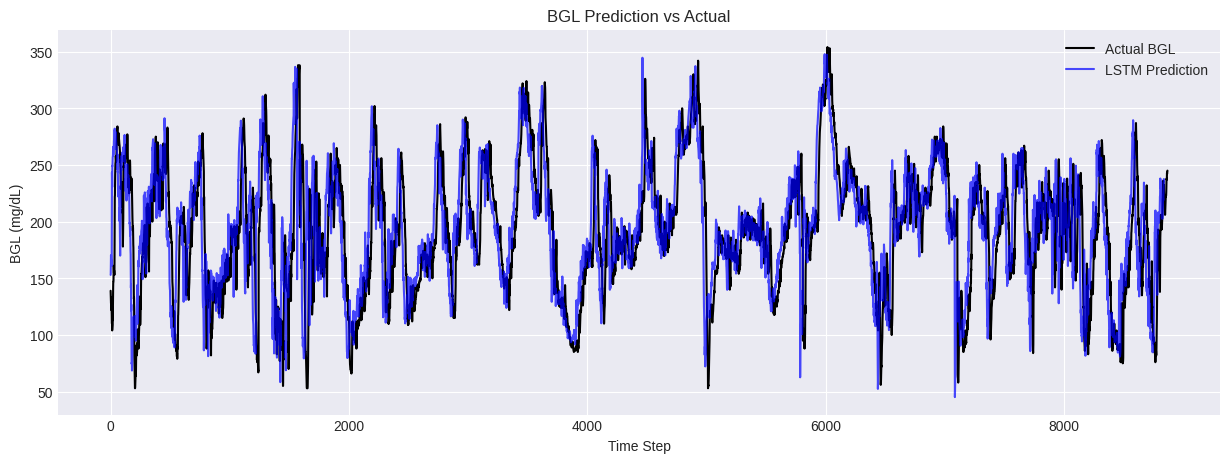

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(test_data['bgl'].values[:len(hmm_pred_final)], label='Actual BGL', color='black')
plt.plot(lstm_pred.flatten(), label='LSTM Prediction', color='blue', alpha=0.7)
# If you have other models, plot them too:
# plt.plot(model2_pred, label='Random Forest', color='blue', alpha=0.7)
# plt.plot(model3_pred, label='ARIMA', color='green', alpha=0.7)
plt.title("BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()


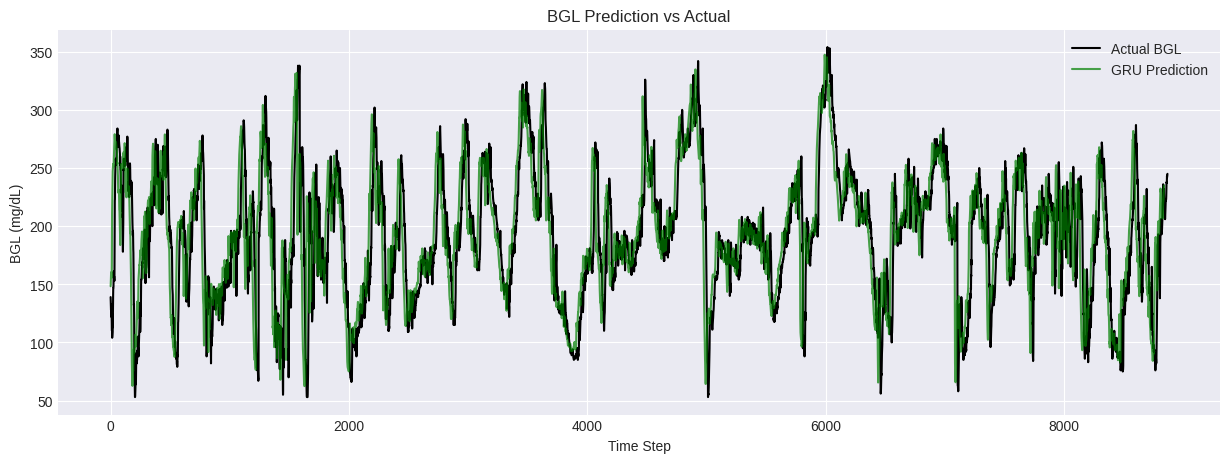

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(test_data['bgl'].values[:len(hmm_pred_final)], label='Actual BGL', color='black')
plt.plot(gru_pred.flatten(), label='GRU Prediction', color='green', alpha=0.7)
# If you have other models, plot them too:
# plt.plot(model2_pred, label='Random Forest', color='blue', alpha=0.7)
# plt.plot(model3_pred, label='ARIMA', color='green', alpha=0.7)
plt.title("BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()


In [169]:
def sanity_check(name, y_true, y_pred):
    print(f"\n{name} Sanity Check")
    print("Actual min/max:", y_true.min(), y_true.max())
    print("Pred min/max:", y_pred.min(), y_pred.max())
    print("Mean Actual:", y_true.mean())
    print("Mean Pred:", y_pred.mean())


In [170]:
sanity_check("HMM", y_test_inv.flatten(), hmm_pred_final.flatten())
sanity_check("LSTM", y_test_inv.flatten(), lstm_pred.flatten())
sanity_check("GRU", y_test_inv.flatten(), gru_pred.flatten())



HMM Sanity Check
Actual min/max: 53.0 354.0
Pred min/max: 83.47749463961748 327.9720267039612
Mean Actual: 192.91965599185244
Mean Pred: 192.84801643106613

LSTM Sanity Check
Actual min/max: 53.0 354.0
Pred min/max: 45.20833 347.74612
Mean Actual: 192.91965599185244
Mean Pred: 194.13324

GRU Sanity Check
Actual min/max: 53.0 354.0
Pred min/max: 62.424248 347.4094
Mean Actual: 192.91965599185244
Mean Pred: 192.85916


In [171]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{name} TEST RESULTS")
    print(f"MAE  = {mae:.2f}")
    print(f"RMSE = {rmse:.2f}")
    print(f"MAPE = {mape:.2f}%")

    return mae, rmse, mape


In [172]:
evaluate_model("HMM", test_actual.values, hmm_pred_final.flatten())
evaluate_model("LSTM", y_test_inv.flatten(), lstm_pred.flatten())
evaluate_model("GRU",  y_test_inv.flatten(), gru_pred.flatten())



HMM TEST RESULTS
MAE  = 5.17
RMSE = 7.01
MAPE = 3.16%

LSTM TEST RESULTS
MAE  = 13.09
RMSE = 18.50
MAPE = 7.90%

GRU TEST RESULTS
MAE  = 14.05
RMSE = 19.80
MAPE = 8.45%


(14.046857832351447,
 np.float64(19.803147703431108),
 np.float64(8.450929435908215))

In [173]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}") # Commented out to avoid redundant printing if already printed by evaluate_model
    return rmse, mae

# Assuming lstm_model, gru_model, hmm_model, X_train, y_train, X_test, y_test, train_scaled, test_scaled are already defined and populated.

# LSTM Predictions and Metrics
print("LSTM RESULTS")
lstm_train_pred = lstm_model.predict(X_train).flatten()
lstm_test_pred  = lstm_model.predict(X_test).flatten()
lstm_train_rmse, lstm_train_mae = evaluate(y_train.flatten(), lstm_train_pred, "LSTM Train")
lstm_test_rmse, lstm_test_mae   = evaluate(y_test.flatten(), lstm_test_pred, "LSTM Test")

# GRU Predictions and Metrics
print("\nGRU RESULTS")
gru_train_pred = gru_model.predict(X_train).flatten()
gru_test_pred  = gru_model.predict(X_test).flatten()
gru_train_rmse, gru_train_mae = evaluate(y_train.flatten(), gru_train_pred, "GRU Train")
gru_test_rmse, gru_test_mae   = evaluate(y_test.flatten(), gru_test_pred, "GRU Test")

# HMM Predictions and Metrics
print("\nHMM RESULTS")
hmm_train_states = hmm_model.predict(train_scaled)
hmm_test_states  = hmm_model.predict(test_scaled)
hmm_means = hmm_model.means_.flatten()
hmm_train_pred = np.array([hmm_means[s] for s in hmm_train_states])
hmm_test_pred  = np.array([hmm_means[s] for s in hmm_test_states])

hmm_train_rmse, hmm_train_mae = evaluate(train_scaled.flatten(), hmm_train_pred, "HMM Train")
hmm_test_rmse, hmm_test_mae   = evaluate(test_scaled.flatten(), hmm_test_pred, "HMM Test")

results = pd.DataFrame({
    "Model": ["LSTM", "GRU", "HMM"],
    "Train RMSE": [lstm_train_rmse, gru_train_rmse, hmm_train_rmse],
    "Test RMSE":  [lstm_test_rmse,  gru_test_rmse,  hmm_test_rmse],
    "Train MAE":  [lstm_train_mae,  gru_train_mae,  hmm_train_mae],
    "Test MAE":   [lstm_test_mae,   gru_test_mae,   hmm_test_mae]
})

print("\nComparison of Model Performance:")
print(results)
results

LSTM RESULTS
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

GRU RESULTS
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

HMM RESULTS

Comparison of Model Performance:
  Model  Train RMSE  Test RMSE  Train MAE  Test MAE
0  LSTM    0.055317   0.051384   0.038232  0.036358
1   GRU    0.059066   0.055009   0.040936  0.039019
2   HMM    0.025607   0.022585   0.019927  0.018348


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE
0,LSTM,0.055317,0.051384,0.038232,0.036358
1,GRU,0.059066,0.055009,0.040936,0.039019
2,HMM,0.025607,0.022585,0.019927,0.018348


In [174]:
print("Aligning prediction and actual arrays for ensemble...")

# Ensure all prediction arrays are 1D before finding minimum length
# This step also handles potential discrepancies in how they are stored (e.g., (N,1) vs (N,))
lstm_pred_flat = lstm_pred.flatten()
gru_pred_flat = gru_pred.flatten()
hmm_pred_final_flat = hmm_pred_final.flatten()

# Determine the minimum length among the predictions and actuals
min_len = min(len(lstm_pred_flat), len(gru_pred_flat), len(hmm_pred_final_flat), len(y_test_inv.flatten()), len(test_actual))

# Truncate all arrays to the minimum length
lstm_pred_aligned = lstm_pred_flat[:min_len]
gru_pred_aligned = gru_pred_flat[:min_len]
hmm_pred_aligned = hmm_pred_final_flat[:min_len]

# Truncate actual values as well. Use y_test_inv as the common actuals.
y_test_inv_aligned = y_test_inv.flatten()[:min_len]

print(f"All arrays aligned to a length of {min_len} samples.")
print(f"  LSTM Predictions shape: {lstm_pred_aligned.shape}")
print(f"  GRU Predictions shape: {gru_pred_aligned.shape}")
print(f"  HMM Predictions shape: {hmm_pred_aligned.shape}")
print(f"  Actual values shape: {y_test_inv_aligned.shape}")

Aligning prediction and actual arrays for ensemble...
All arrays aligned to a length of 8837 samples.
  LSTM Predictions shape: (8837,)
  GRU Predictions shape: (8837,)
  HMM Predictions shape: (8837,)
  Actual values shape: (8837,)


In [175]:
lstm_hmm_ensemble_pred = (lstm_pred_aligned + hmm_pred_aligned) / 2

print("Ensemble Prediction created by averaging LSTM and HMM predictions.")

# Evaluate the ensemble model
evaluate_model("LSTM-HMM Ensemble", y_test_inv_aligned, lstm_hmm_ensemble_pred)

Ensemble Prediction created by averaging LSTM and HMM predictions.

LSTM-HMM Ensemble TEST RESULTS
MAE  = 20.90
RMSE = 28.21
MAPE = 12.86%


(20.898786343607405,
 np.float64(28.213014380456855),
 np.float64(12.8586465668101))

In [176]:
lstm_gru_ensemble_pred = (lstm_pred_aligned + gru_pred_aligned) / 2

print("Ensemble Prediction created by averaging LSTM and GRU predictions.")

# Evaluate the ensemble model
evaluate_model("LSTM-GRU Ensemble", y_test_inv_aligned, lstm_gru_ensemble_pred)

Ensemble Prediction created by averaging LSTM and GRU predictions.

LSTM-GRU Ensemble TEST RESULTS
MAE  = 13.29
RMSE = 18.80
MAPE = 8.00%


(13.293303410796756,
 np.float64(18.801156614900638),
 np.float64(8.004911698844479))

In [177]:
hmm_gru_ensemble_pred = (hmm_pred_aligned + gru_pred_aligned) / 2

print("Ensemble Prediction created by averaging HMM and GRU predictions.")

# Evaluate the ensemble model
evaluate_model("HMM-GRU Ensemble", y_test_inv_aligned, hmm_gru_ensemble_pred)

Ensemble Prediction created by averaging HMM and GRU predictions.

HMM-GRU Ensemble TEST RESULTS
MAE  = 22.15
RMSE = 29.86
MAPE = 13.53%


(22.147536026163454,
 np.float64(29.859762963051995),
 np.float64(13.527999270452348))

In [178]:
model_metrics = []

# Individual models
mae, rmse, mape = evaluate_model("LSTM", y_test_inv.flatten(), lstm_pred.flatten())
model_metrics.append({'Model': 'LSTM', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

mae, rmse, mape = evaluate_model("GRU", y_test_inv.flatten(), gru_pred.flatten())
model_metrics.append({'Model': 'GRU', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

mae, rmse, mape = evaluate_model("HMM", test_actual.values, hmm_pred_final.flatten())
model_metrics.append({'Model': 'HMM', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

# Ensemble models
mae, rmse, mape = evaluate_model("LSTM-HMM Ensemble", y_test_inv_aligned, lstm_hmm_ensemble_pred)
model_metrics.append({'Model': 'LSTM-HMM Ensemble', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

mae, rmse, mape = evaluate_model("LSTM-GRU Ensemble", y_test_inv_aligned, lstm_gru_ensemble_pred)
model_metrics.append({'Model': 'LSTM-GRU Ensemble', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

mae, rmse, mape = evaluate_model("HMM-GRU Ensemble", y_test_inv_aligned, hmm_gru_ensemble_pred)
model_metrics.append({'Model': 'HMM-GRU Ensemble', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

# Create DataFrame
comparison_df = pd.DataFrame(model_metrics)

print("\n--- Model Performance Comparison ---")
print(comparison_df.to_string(index=False))


LSTM TEST RESULTS
MAE  = 13.09
RMSE = 18.50
MAPE = 7.90%

GRU TEST RESULTS
MAE  = 14.05
RMSE = 19.80
MAPE = 8.45%

HMM TEST RESULTS
MAE  = 5.17
RMSE = 7.01
MAPE = 3.16%

LSTM-HMM Ensemble TEST RESULTS
MAE  = 20.90
RMSE = 28.21
MAPE = 12.86%

LSTM-GRU Ensemble TEST RESULTS
MAE  = 13.29
RMSE = 18.80
MAPE = 8.00%

HMM-GRU Ensemble TEST RESULTS
MAE  = 22.15
RMSE = 29.86
MAPE = 13.53%

--- Model Performance Comparison ---
            Model       MAE      RMSE      MAPE  Accuracy
             LSTM 13.088974 18.498063  7.902566 92.097434
              GRU 14.046858 19.803148  8.450929 91.549071
              HMM  5.169188  7.013843  3.158859 96.841141
LSTM-HMM Ensemble 20.898786 28.213014 12.858647 87.141353
LSTM-GRU Ensemble 13.293303 18.801157  8.004912 91.995088
 HMM-GRU Ensemble 22.147536 29.859763 13.527999 86.472001


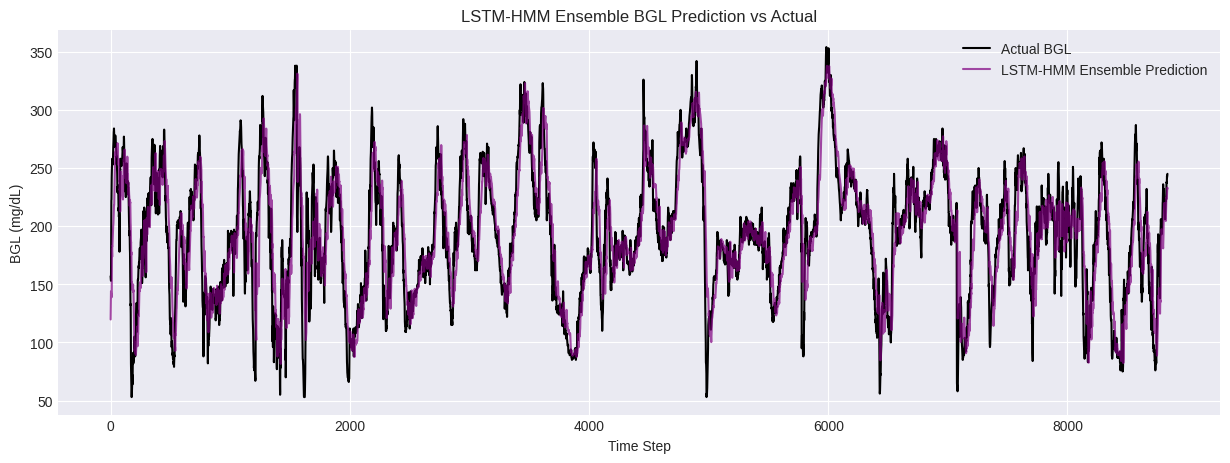

In [179]:
import matplotlib.pyplot as plt

# Plot for LSTM-HMM Ensemble
plt.figure(figsize=(15,5))
plt.plot(y_test_inv_aligned, label='Actual BGL', color='black')
plt.plot(lstm_hmm_ensemble_pred, label='LSTM-HMM Ensemble Prediction', color='purple', alpha=0.7)
plt.title("LSTM-HMM Ensemble BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()

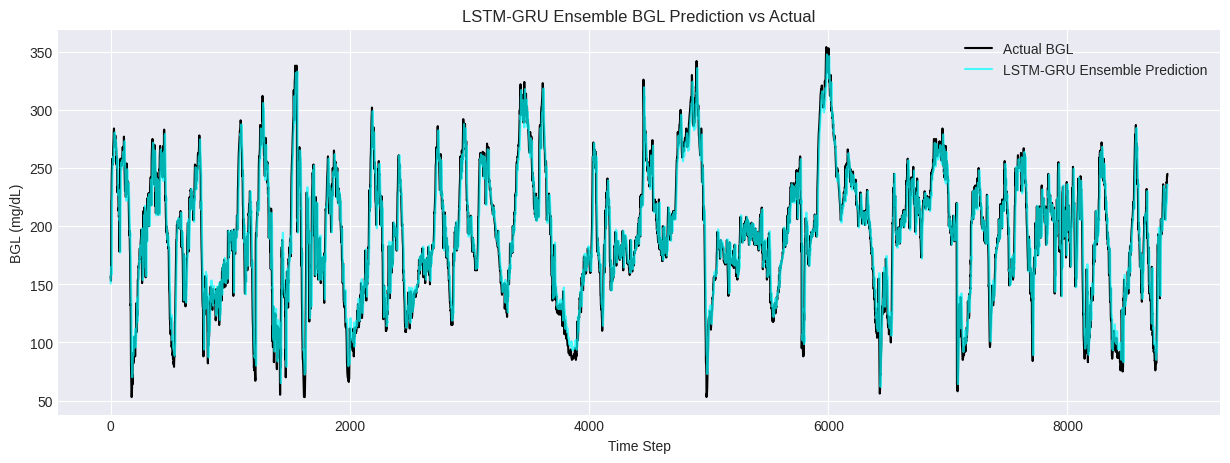

In [180]:
import matplotlib.pyplot as plt

# Plot for LSTM-GRU Ensemble
plt.figure(figsize=(15,5))
plt.plot(y_test_inv_aligned, label='Actual BGL', color='black')
plt.plot(lstm_gru_ensemble_pred, label='LSTM-GRU Ensemble Prediction', color='cyan', alpha=0.7)
plt.title("LSTM-GRU Ensemble BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()

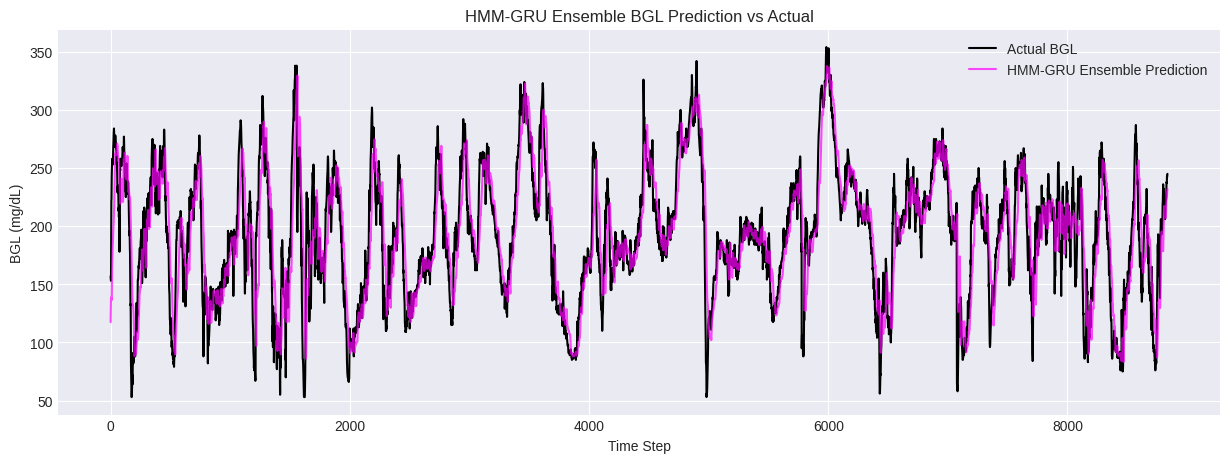

In [181]:
import matplotlib.pyplot as plt

# Plot for HMM-GRU Ensemble
plt.figure(figsize=(15,5))
plt.plot(y_test_inv_aligned, label='Actual BGL', color='black')
plt.plot(hmm_gru_ensemble_pred, label='HMM-GRU Ensemble Prediction', color='magenta', alpha=0.7)
plt.title("HMM-GRU Ensemble BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()

In [182]:
# Create DataFrame
comparison_df = pd.DataFrame(model_metrics)

# Print as a table using tabulate
print("\n--- Model Performance Comparison ---")
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))


--- Model Performance Comparison ---
+-------------------+----------+----------+----------+------------+
| Model             |      MAE |     RMSE |     MAPE |   Accuracy |
+===================+==========+==========+==========+============+
| LSTM              | 13.089   | 18.4981  |  7.90257 |    92.0974 |
+-------------------+----------+----------+----------+------------+
| GRU               | 14.0469  | 19.8031  |  8.45093 |    91.5491 |
+-------------------+----------+----------+----------+------------+
| HMM               |  5.16919 |  7.01384 |  3.15886 |    96.8411 |
+-------------------+----------+----------+----------+------------+
| LSTM-HMM Ensemble | 20.8988  | 28.213   | 12.8586  |    87.1414 |
+-------------------+----------+----------+----------+------------+
| LSTM-GRU Ensemble | 13.2933  | 18.8012  |  8.00491 |    91.9951 |
+-------------------+----------+----------+----------+------------+
| HMM-GRU Ensemble  | 22.1475  | 29.8598  | 13.528   |    86.472  |
+---------

In [183]:
gru_model.summary()
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,789 (151.52 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,885 (198.77 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,924 (132.52 KB)

# Dense Model

In [184]:
# STEP 1: Build the Dense model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

dense_model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

dense_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [185]:
# STEP 2: Train it
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
dense_model.compile(optimizer='adam', loss='mse')

history_dense = dense_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0059 - val_loss: 0.0025
Epoch 2/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - val_loss: 0.0026
Epoch 3/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - val_loss: 0.0026
Epoch 4/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 5/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 6/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0026
Epoch 7/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 8/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 9/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 10/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0025


In [186]:
# Evaluate it
from sklearn.metrics import mean_absolute_error, mean_squared_error

dense_pred_scaled = dense_model.predict(X_test)
dense_pred = scaler.inverse_transform(dense_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test)

dense_mae  = mean_absolute_error(y_test_inv, dense_pred)
dense_rmse = np.sqrt(mean_squared_error(y_test_inv, dense_pred))
dense_mape = np.mean(np.abs((y_test_inv - dense_pred) / y_test_inv)) * 100

print(f"\nDense Model Results:")
print(f"  MAE      : {dense_mae:.2f} mg/dL")
print(f"  RMSE     : {dense_rmse:.2f} mg/dL")
print(f"  MAPE     : {dense_mape:.2f}%")
print(f"  Accuracy : {100 - dense_mape:.2f}%")

277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Dense Model Results:
  MAE      : 13.31 mg/dL
  RMSE     : 18.85 mg/dL
  MAPE     : 7.85%
  Accuracy : 92.15%


In [187]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

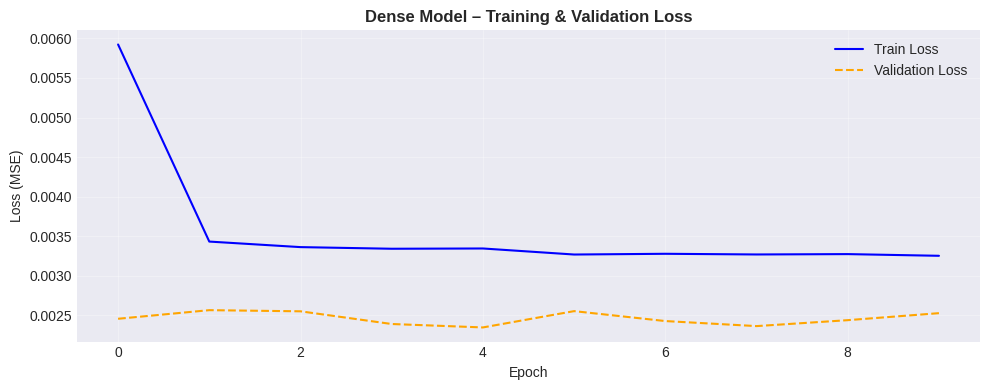

In [188]:
plt.figure(figsize=(10, 4))
plt.plot(history_dense.history['loss'],     label='Train Loss',      color='blue',   linewidth=1.5)
plt.plot(history_dense.history['val_loss'], label='Validation Loss', color='orange', linewidth=1.5, linestyle='--')
plt.title('Dense Model – Training & Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

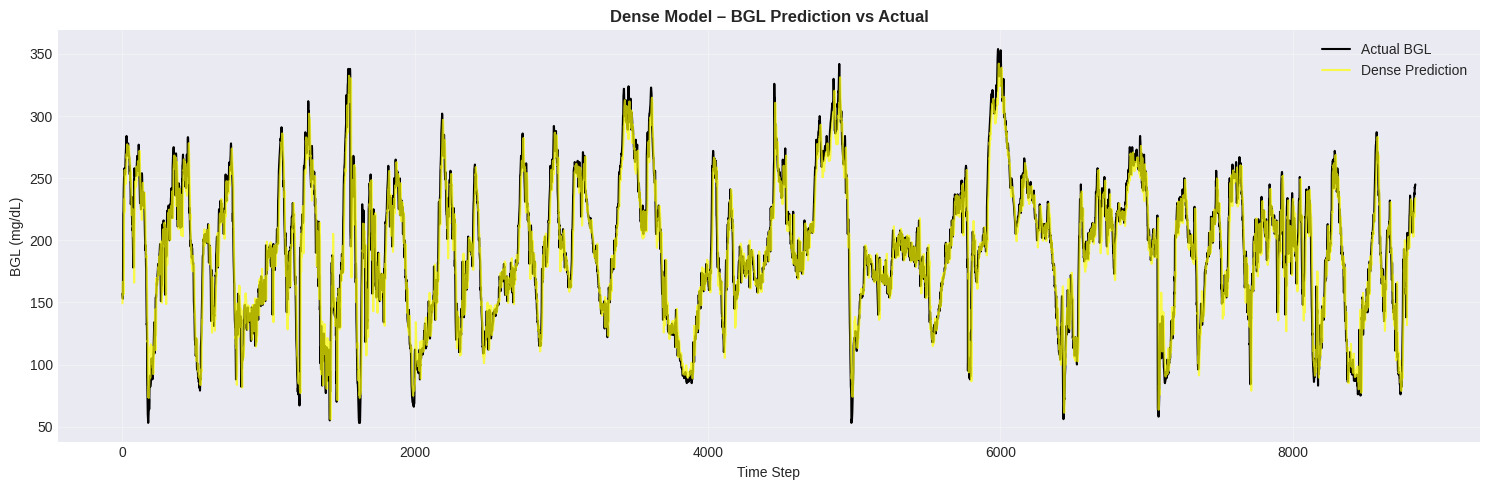

In [189]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_inv,              label='Actual BGL',       color='black')
plt.plot(dense_pred.flatten(),    label='Dense Prediction', color='yellow', alpha=0.7)
plt.title('Dense Model – BGL Prediction vs Actual', fontweight='bold')
plt.xlabel('Time Step')
plt.ylabel('BGL (mg/dL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [190]:
dense_mae  = mean_absolute_error(y_test_inv, dense_pred)
dense_rmse = np.sqrt(mean_squared_error(y_test_inv, dense_pred))
dense_mape = np.mean(np.abs((y_test_inv - dense_pred) / y_test_inv)) * 100

print(f"Dense Model Results:")
print(f"  MAE      : {dense_mae:.2f} mg/dL")
print(f"  RMSE     : {dense_rmse:.2f} mg/dL")
print(f"  MAPE     : {dense_mape:.2f}%")
print(f"  Accuracy : {100 - dense_mape:.2f}%")

Dense Model Results:
  MAE      : 13.31 mg/dL
  RMSE     : 18.85 mg/dL
  MAPE     : 7.85%
  Accuracy : 92.15%


In [191]:
model_metrics.append({
    'Model':    'Dense',
    'MAE':      dense_mae,
    'RMSE':     dense_rmse,
    'MAPE':     dense_mape,
    'Accuracy': 100 - dense_mape
})

comparison_df = pd.DataFrame(model_metrics)
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

+-------------------+----------+----------+----------+------------+
| Model             |      MAE |     RMSE |     MAPE |   Accuracy |
+===================+==========+==========+==========+============+
| LSTM              | 13.089   | 18.4981  |  7.90257 |    92.0974 |
+-------------------+----------+----------+----------+------------+
| GRU               | 14.0469  | 19.8031  |  8.45093 |    91.5491 |
+-------------------+----------+----------+----------+------------+
| HMM               |  5.16919 |  7.01384 |  3.15886 |    96.8411 |
+-------------------+----------+----------+----------+------------+
| LSTM-HMM Ensemble | 20.8988  | 28.213   | 12.8586  |    87.1414 |
+-------------------+----------+----------+----------+------------+
| LSTM-GRU Ensemble | 13.2933  | 18.8012  |  8.00491 |    91.9951 |
+-------------------+----------+----------+----------+------------+
| HMM-GRU Ensemble  | 22.1475  | 29.8598  | 13.528   |    86.472  |
+-------------------+----------+----------+-----

In [192]:
# Re-print the comparison table with the Dense model included for clarity
comparison_df = pd.DataFrame(model_metrics)
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

+-------------------+----------+----------+----------+------------+
| Model             |      MAE |     RMSE |     MAPE |   Accuracy |
+===================+==========+==========+==========+============+
| LSTM              | 13.089   | 18.4981  |  7.90257 |    92.0974 |
+-------------------+----------+----------+----------+------------+
| GRU               | 14.0469  | 19.8031  |  8.45093 |    91.5491 |
+-------------------+----------+----------+----------+------------+
| HMM               |  5.16919 |  7.01384 |  3.15886 |    96.8411 |
+-------------------+----------+----------+----------+------------+
| LSTM-HMM Ensemble | 20.8988  | 28.213   | 12.8586  |    87.1414 |
+-------------------+----------+----------+----------+------------+
| LSTM-GRU Ensemble | 13.2933  | 18.8012  |  8.00491 |    91.9951 |
+-------------------+----------+----------+----------+------------+
| HMM-GRU Ensemble  | 22.1475  | 29.8598  | 13.528   |    86.472  |
+-------------------+----------+----------+-----

In [193]:
print(f"Scaler min: {scaler.data_min_[0]}")
print(f"Scaler max: {scaler.data_max_[0]}")

Scaler min: 40.0
Scaler max: 400.0


  HMM OVERFITTING DIAGNOSTIC

1. Train vs Test Performance Gap
   Metric        Train       Test        Gap
   ----------------------------------------
   MAE            5.86       5.17       0.69
   RMSE           8.29       7.01       1.28
   MAPE           3.56%       3.16%      0.40%
   Accuracy     96.44%     96.84%

   ✅ MAPE gap is 0.40% — no significant overfitting detected.

2. Rolling-Window Generalisation (test set split into 3 chunks)
   Chunk 1: MAPE = 3.53%  Accuracy = 96.47%
   Chunk 2: MAPE = 2.88%  Accuracy = 97.12%
   Chunk 3: MAPE = 3.16%  Accuracy = 96.84%

   ✅ Std across chunks = 0.26% — stable generalisation.

3. Residual Analysis
   Mean residual : -0.13 mg/dL  (should be ~0 if unbiased)
   Std  residual : 7.01 mg/dL
   ✅ Residuals are centred — no systematic bias.


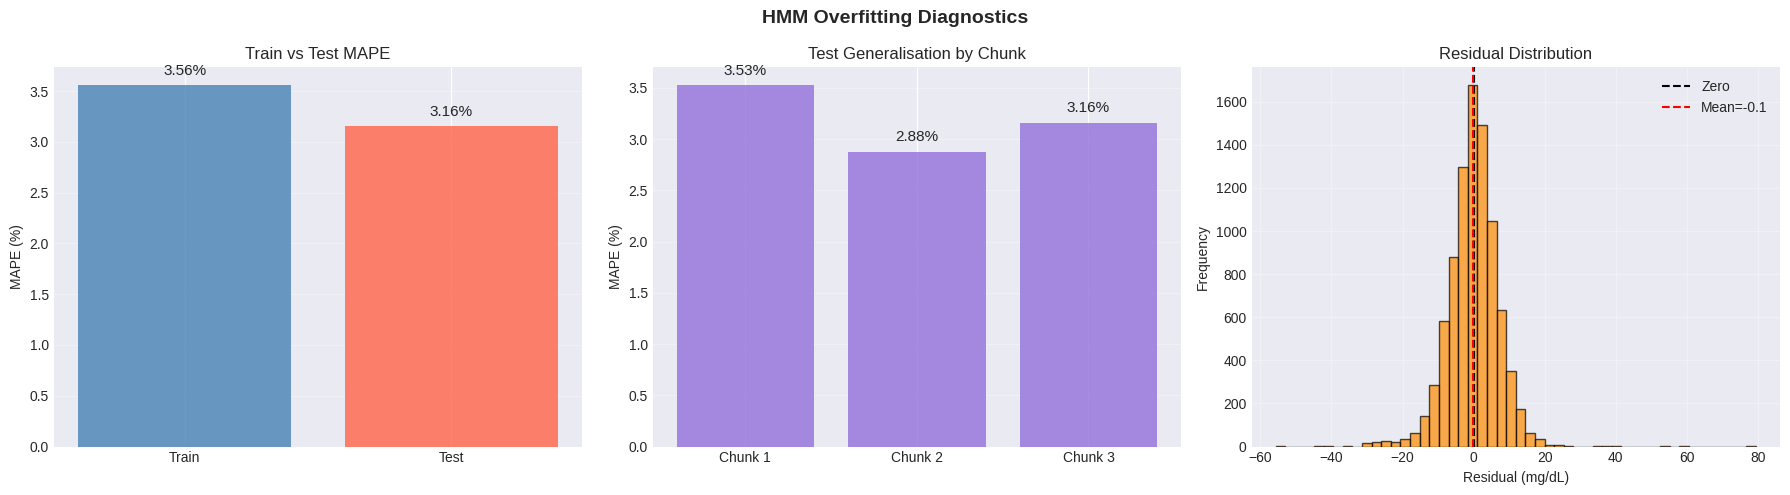


  Diagnostic complete.


In [194]:
# ── HMM Overfitting Diagnostic ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 60)
print("  HMM OVERFITTING DIAGNOSTIC")
print("=" * 60)

# ── 1. Train vs Test performance gap ────────────────────────────────────────
# Re-run HMM on training data using the same prediction pipeline
train_state_probs  = hmm_model.predict_proba(train_scaled)
hmm_means_flat     = hmm_model.means_.flatten()
train_pred_weighted = (train_state_probs * hmm_means_flat).sum(axis=1)
train_pred_smooth  = np.convolve(train_pred_weighted, np.ones(5)/5, mode='same')
train_pred_final   = scaler.inverse_transform(train_pred_smooth.reshape(-1, 1))

train_actual = train_data['bgl'].values[:len(train_pred_final)]

train_mae  = mean_absolute_error(train_actual, train_pred_final)
train_rmse = np.sqrt(mean_squared_error(train_actual, train_pred_final))
train_mape = np.mean(np.abs((train_actual - train_pred_final.flatten()) / train_actual)) * 100

print(f"\n1. Train vs Test Performance Gap")
print(f"   {'Metric':<8} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"   {'-'*40}")
print(f"   {'MAE':<8} {train_mae:>10.2f} {hmm_mae:>10.2f} {abs(hmm_mae - train_mae):>10.2f}")
print(f"   {'RMSE':<8} {train_rmse:>10.2f} {hmm_rmse:>10.2f} {abs(hmm_rmse - train_rmse):>10.2f}")
print(f"   {'MAPE':<8} {train_mape:>10.2f}% {hmm_mape:>10.2f}% {abs(hmm_mape - train_mape):>9.2f}%")
print(f"   {'Accuracy':<8} {100-train_mape:>9.2f}% {100-hmm_mape:>9.2f}%")

gap = abs(hmm_mape - train_mape)
if gap < 2:
    print(f"\n   ✅ MAPE gap is {gap:.2f}% — no significant overfitting detected.")
elif gap < 5:
    print(f"\n   ⚠️  MAPE gap is {gap:.2f}% — mild overfitting, monitor carefully.")
else:
    print(f"\n   ❌ MAPE gap is {gap:.2f}% — likely overfitting. Consider fewer states.")

# ── 2. Rolling-window generalisation test ───────────────────────────────────
# Split test set into 3 equal chunks; if performance degrades over time,
# the model is memorising the training distribution rather than generalising.
print(f"\n2. Rolling-Window Generalisation (test set split into 3 chunks)")
chunk_size = len(test_scaled) // 3
chunk_mapes = []
for k in range(3):
    chunk = test_scaled[k*chunk_size:(k+1)*chunk_size]
    chunk_actual = test_data['bgl'].values[k*chunk_size:(k+1)*chunk_size]
    sp = hmm_model.predict_proba(chunk)
    pw = (sp * hmm_means_flat).sum(axis=1)
    ps = np.convolve(pw, np.ones(5)/5, mode='same')
    pf = scaler.inverse_transform(ps.reshape(-1, 1)).flatten()
    m  = np.mean(np.abs((chunk_actual - pf) / chunk_actual)) * 100
    chunk_mapes.append(m)
    print(f"   Chunk {k+1}: MAPE = {m:.2f}%  Accuracy = {100-m:.2f}%")

mape_std = np.std(chunk_mapes)
if mape_std < 1.5:
    print(f"\n   ✅ Std across chunks = {mape_std:.2f}% — stable generalisation.")
else:
    print(f"\n   ⚠️  Std across chunks = {mape_std:.2f}% — performance varies across time.")

# ── 3. Residual analysis ────────────────────────────────────────────────────
residuals = test_data['bgl'].values[:len(hmm_pred_final)] - hmm_pred_final.flatten()
residual_mean = residuals.mean()
residual_std  = residuals.std()

print(f"\n3. Residual Analysis")
print(f"   Mean residual : {residual_mean:.2f} mg/dL  (should be ~0 if unbiased)")
print(f"   Std  residual : {residual_std:.2f} mg/dL")
if abs(residual_mean) < 5:
    print(f"   ✅ Residuals are centred — no systematic bias.")
else:
    print(f"   ⚠️  Non-zero mean residual — model has a systematic bias of {residual_mean:.2f} mg/dL.")

# ── 4. Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HMM Overfitting Diagnostics', fontsize=14, fontweight='bold')

# 4a. Train vs Test MAPE bar chart
axes[0].bar(['Train', 'Test'], [train_mape, hmm_mape], color=['steelblue', 'tomato'], alpha=0.8)
axes[0].set_title('Train vs Test MAPE')
axes[0].set_ylabel('MAPE (%)')
axes[0].grid(True, axis='y', alpha=0.3)
for j, v in enumerate([train_mape, hmm_mape]):
    axes[0].text(j, v + 0.1, f'{v:.2f}%', ha='center', fontsize=11)

# 4b. Rolling chunk MAPE
axes[1].bar([f'Chunk {k+1}' for k in range(3)], chunk_mapes, color='mediumpurple', alpha=0.8)
axes[1].set_title('Test Generalisation by Chunk')
axes[1].set_ylabel('MAPE (%)')
axes[1].grid(True, axis='y', alpha=0.3)
for j, v in enumerate(chunk_mapes):
    axes[1].text(j, v + 0.1, f'{v:.2f}%', ha='center', fontsize=11)

# 4c. Residual distribution
axes[2].hist(residuals, bins=50, color='darkorange', edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero')
axes[2].axvline(residual_mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean={residual_mean:.1f}')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual (mg/dL)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("  Diagnostic complete.")
print("=" * 60)


In [195]:
print("Aligning all prediction and actual arrays for a combined plot...")

# Ensure all prediction arrays are 1D before finding minimum length
lstm_pred_flat = lstm_pred.flatten()
gru_pred_flat = gru_pred.flatten()
hmm_pred_flat = hmm_pred_final.flatten()
dense_pred_flat = dense_pred.flatten()

# Determine the minimum length among all predictions and actuals
min_len_combined = min(
    len(lstm_pred_flat),
    len(gru_pred_flat),
    len(hmm_pred_flat),
    len(dense_pred_flat),
    len(y_test_inv.flatten())
)

# Truncate all arrays to the minimum length
lstm_pred_aligned_combined = lstm_pred_flat[:min_len_combined]
gru_pred_aligned_combined = gru_pred_flat[:min_len_combined]
hmm_pred_aligned_combined = hmm_pred_flat[:min_len_combined]
dense_pred_aligned_combined = dense_pred_flat[:min_len_combined]

# Truncate actual values as well. Use y_test_inv as the common actuals.
y_test_inv_aligned_combined = y_test_inv.flatten()[:min_len_combined]

print(f"All arrays aligned to a length of {min_len_combined} samples for combined plotting.")

Aligning all prediction and actual arrays for a combined plot...
All arrays aligned to a length of 8837 samples for combined plotting.


In [197]:
import joblib

joblib.dump(hmm_model, 'hmm_model.pkl')
print("HMM model saved to hmm_model.pkl")

HMM model saved to hmm_model.pkl


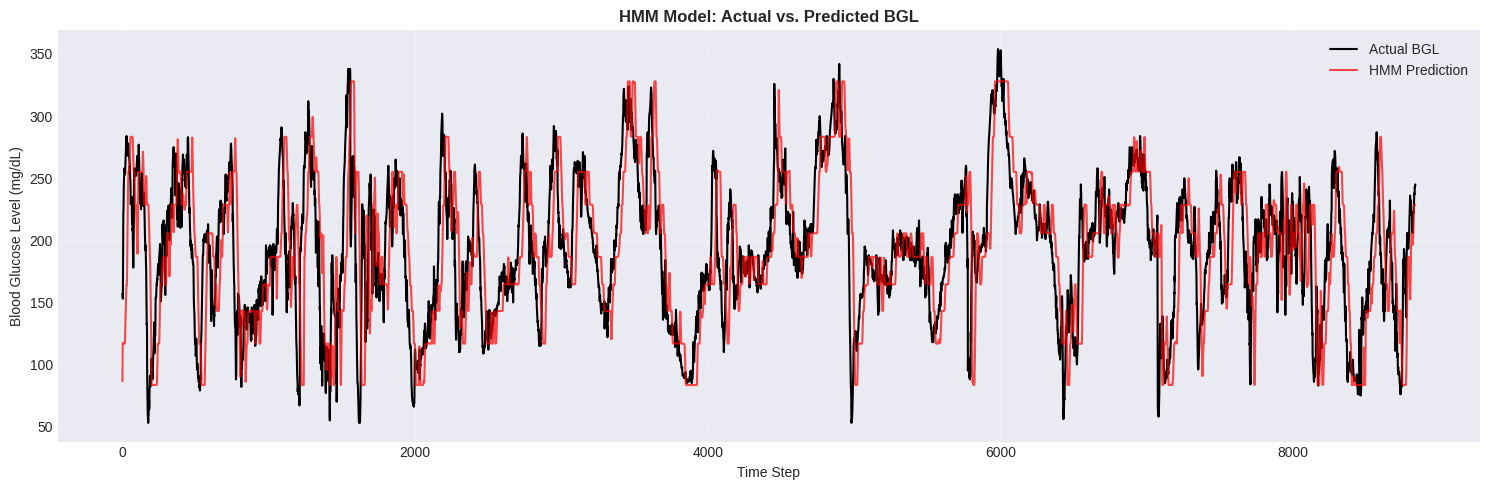

In [198]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_test_inv_aligned, label='Actual BGL', color='black', linewidth=1.5)
plt.plot(hmm_pred_aligned, label='HMM Prediction', color='red', alpha=0.7, linewidth=1.5)
plt.title('HMM Model: Actual vs. Predicted BGL', fontweight='bold')
plt.xlabel('Time Step')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

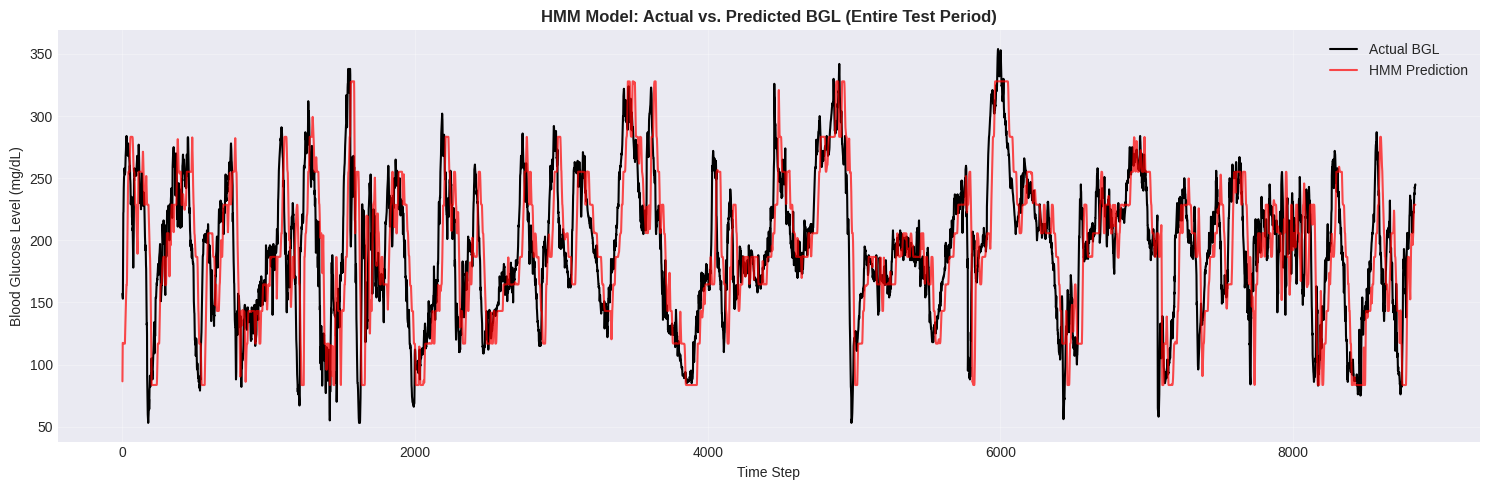

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_test_inv_aligned, label='Actual BGL', color='black', linewidth=1.5)
plt.plot(hmm_pred_aligned, label='HMM Prediction', color='red', alpha=0.7, linewidth=1.5)
plt.title('HMM Model: Actual vs. Predicted BGL (Entire Test Period)', fontweight='bold')
plt.xlabel('Time Step')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [204]:
display(comparison_df)

,Model,MAE,RMSE,MAPE,Accuracy
0,LSTM,13.088974,18.498063,7.902566,92.097434
1,GRU,14.046858,19.803148,8.450929,91.549071
2,HMM,5.169188,7.013843,3.158859,96.841141
3,LSTM-HMM Ensemble,20.898786,28.213014,12.858647,87.141353
4,LSTM-GRU Ensemble,13.293303,18.801157,8.004912,91.995088
5,HMM-GRU Ensemble,22.147536,29.859763,13.527999,86.472001
6,Dense,13.312052,18.852991,7.847094,92.152906


In [202]:
# Add this before plotting to verify
print(f"y_test_inv shape: {y_test_inv.shape}")
print(f"hmm_pred_final shape: {hmm_pred_final.shape}")
print(f"test_data shape: {test_data.shape}")
print(f"Expected test size: ~{int(4323 * 0.2)} samples")

y_test_inv shape: (8837, 1)
hmm_pred_final shape: (8866, 1)
test_data shape: (8866, 1)
Expected test size: ~864 samples


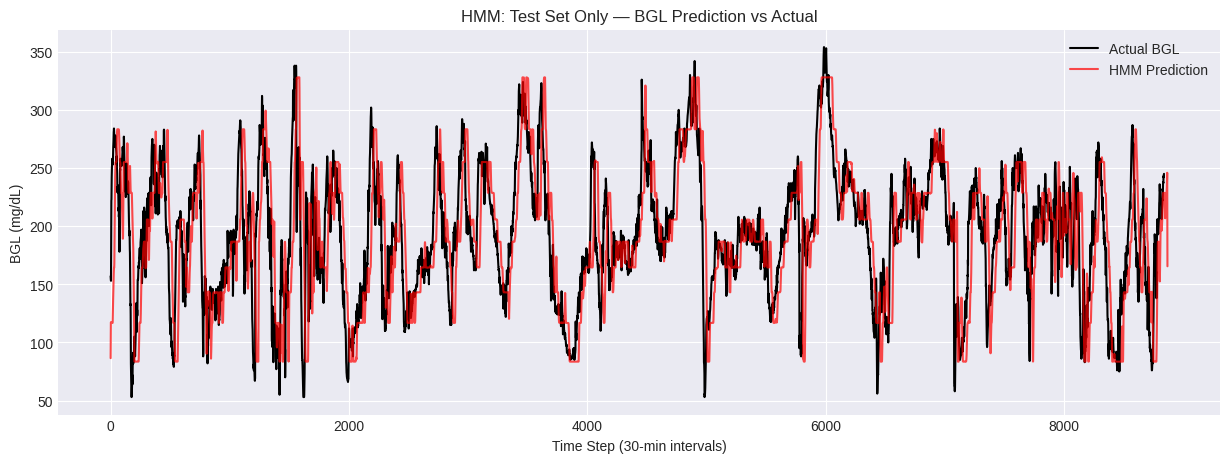

In [203]:
# Correct: only test set
plt.figure(figsize=(15,5))
plt.plot(y_test_inv.flatten(), label='Actual BGL', color='black')
plt.plot(hmm_pred_final.flatten(), label='HMM Prediction', color='red', alpha=0.7)
plt.title("HMM: Test Set Only — BGL Prediction vs Actual")
plt.xlabel("Time Step (30-min intervals)")
plt.ylabel("BGL (mg/dL)")
plt.legend()

plt.show()